# House Prices - Advanced Regression Techniques

> Notebook ini disusun oleh Benedictus Ryu Gunawan

# Data fields
Here's a brief version of what you'll find in the data description file.

- SalePrice: The property's sale price in dollars. This is the target variable that you're trying to predict.
- MSSubClass: The building class
- MSZoning: The general zoning classification
- LotFrontage: Linear feet of street connected to property
- LotArea: Lot size in square feet
- Street: Type of road access
- Alley: Type of alley access
- LotShape: General shape of property
- LandContour: Flatness of the property
- Utilities: Type of utilities available
- LotConfig: Lot configuration
- LandSlope: Slope of property
- Neighborhood: Physical locations within Ames city limits
- Condition1: Proximity to main road or railroad
- Condition2: Proximity to main road or railroad (if a second is present)
- BldgType: Type of dwelling
- HouseStyle: Style of dwelling
- OverallQual: Overall material and finish quality
- OverallCond: Overall condition rating
- YearBuilt: Original construction date
- YearRemodAdd: Remodel date
- RoofStyle: Type of roof
- RoofMatl: Roof material
- Exterior1st: Exterior covering on house
- Exterior2nd: Exterior covering on house (if more than one material)
- MasVnrType: Masonry veneer type
- MasVnrArea: Masonry veneer area in square feet
- ExterQual: Exterior material quality
- ExterCond: Present condition of the material on the exterior
- Foundation: Type of foundation
- BsmtQual: Height of the basement
- BsmtCond: General condition of the basement
- BsmtExposure: Walkout or garden level basement walls
- BsmtFinType1: Quality of basement finished area
- BsmtFinSF1: Type 1 finished square feet
- BsmtFinType2: Quality of second finished area (if present)
- BsmtFinSF2: Type 2 finished square feet
- BsmtUnfSF: Unfinished square feet of basement area
- TotalBsmtSF: Total square feet of basement area
- Heating: Type of heating
- HeatingQC: Heating quality and condition
- CentralAir: Central air conditioning
- Electrical: Electrical system
- 1stFlrSF: First Floor square feet
- 2ndFlrSF: Second floor square feet
- LowQualFinSF: Low quality finished square feet (all floors)
- GrLivArea: Above grade (ground) living area square feet
- BsmtFullBath: Basement full bathrooms
- BsmtHalfBath: Basement half bathrooms
- FullBath: Full bathrooms above grade
- HalfBath: Half baths above grade
- Bedroom: Number of bedrooms above basement level
- Kitchen: Number of kitchens
- KitchenQual: Kitchen quality
- TotRmsAbvGrd: Total rooms above grade (does not include bathrooms)
- Functional: Home functionality rating
- Fireplaces: Number of fireplaces
- FireplaceQu: Fireplace quality
- GarageType: Garage location
- GarageYrBlt: Year garage was built
- GarageFinish: Interior finish of the garage
- GarageCars: Size of garage in car capacity
- GarageArea: Size of garage in square feet
- GarageQual: Garage quality
- GarageCond: Garage condition
- PavedDrive: Paved driveway
- WoodDeckSF: Wood deck area in square feet
- OpenPorchSF: Open porch area in square feet
- EnclosedPorch: Enclosed porch area in square feet
- 3SsnPorch: Three season porch area in square feet
- ScreenPorch: Screen porch area in square feet
- PoolArea: Pool area in square feet
- PoolQC: Pool quality
- Fence: Fence quality
- MiscFeature: Miscellaneous feature not covered in other categories
- MiscVal: $Value of miscellaneous feature
- MoSold: Month Sold
- YrSold: Year Sold
- SaleType: Type of sale
- SaleCondition: Condition of sale

# Environtment Set Up

In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from pathlib import Path

ROOT_DIR = Path(os.getcwd()).parent
DATA_DIR = ROOT_DIR / "data"
OUTPUT_DIR = ROOT_DIR / "output"

SEED = 3407

print(f"Root directory: {ROOT_DIR}")
print(f"Data directory: {DATA_DIR}")
print(f"Output directory: {OUTPUT_DIR}")

Root directory: /home/ryz/data/collage/sem3/datmin/Repo/Week 4/tugas_praproses_data
Data directory: /home/ryz/data/collage/sem3/datmin/Repo/Week 4/tugas_praproses_data/data
Output directory: /home/ryz/data/collage/sem3/datmin/Repo/Week 4/tugas_praproses_data/output


# Get Dataset

In [41]:
df = pd.read_csv(DATA_DIR / "train.csv")
df.index = df["Id"] 
df.drop(columns=["Id"], inplace=True) 

print(f"Dataframe shape: {df.shape}")
display(df.head())

Dataframe shape: (1460, 80)


,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
Id,,,,,,,,,,,,,,,,,,,,,
1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


# Missing Analysis - Missing Preprocessing

<Axes: >

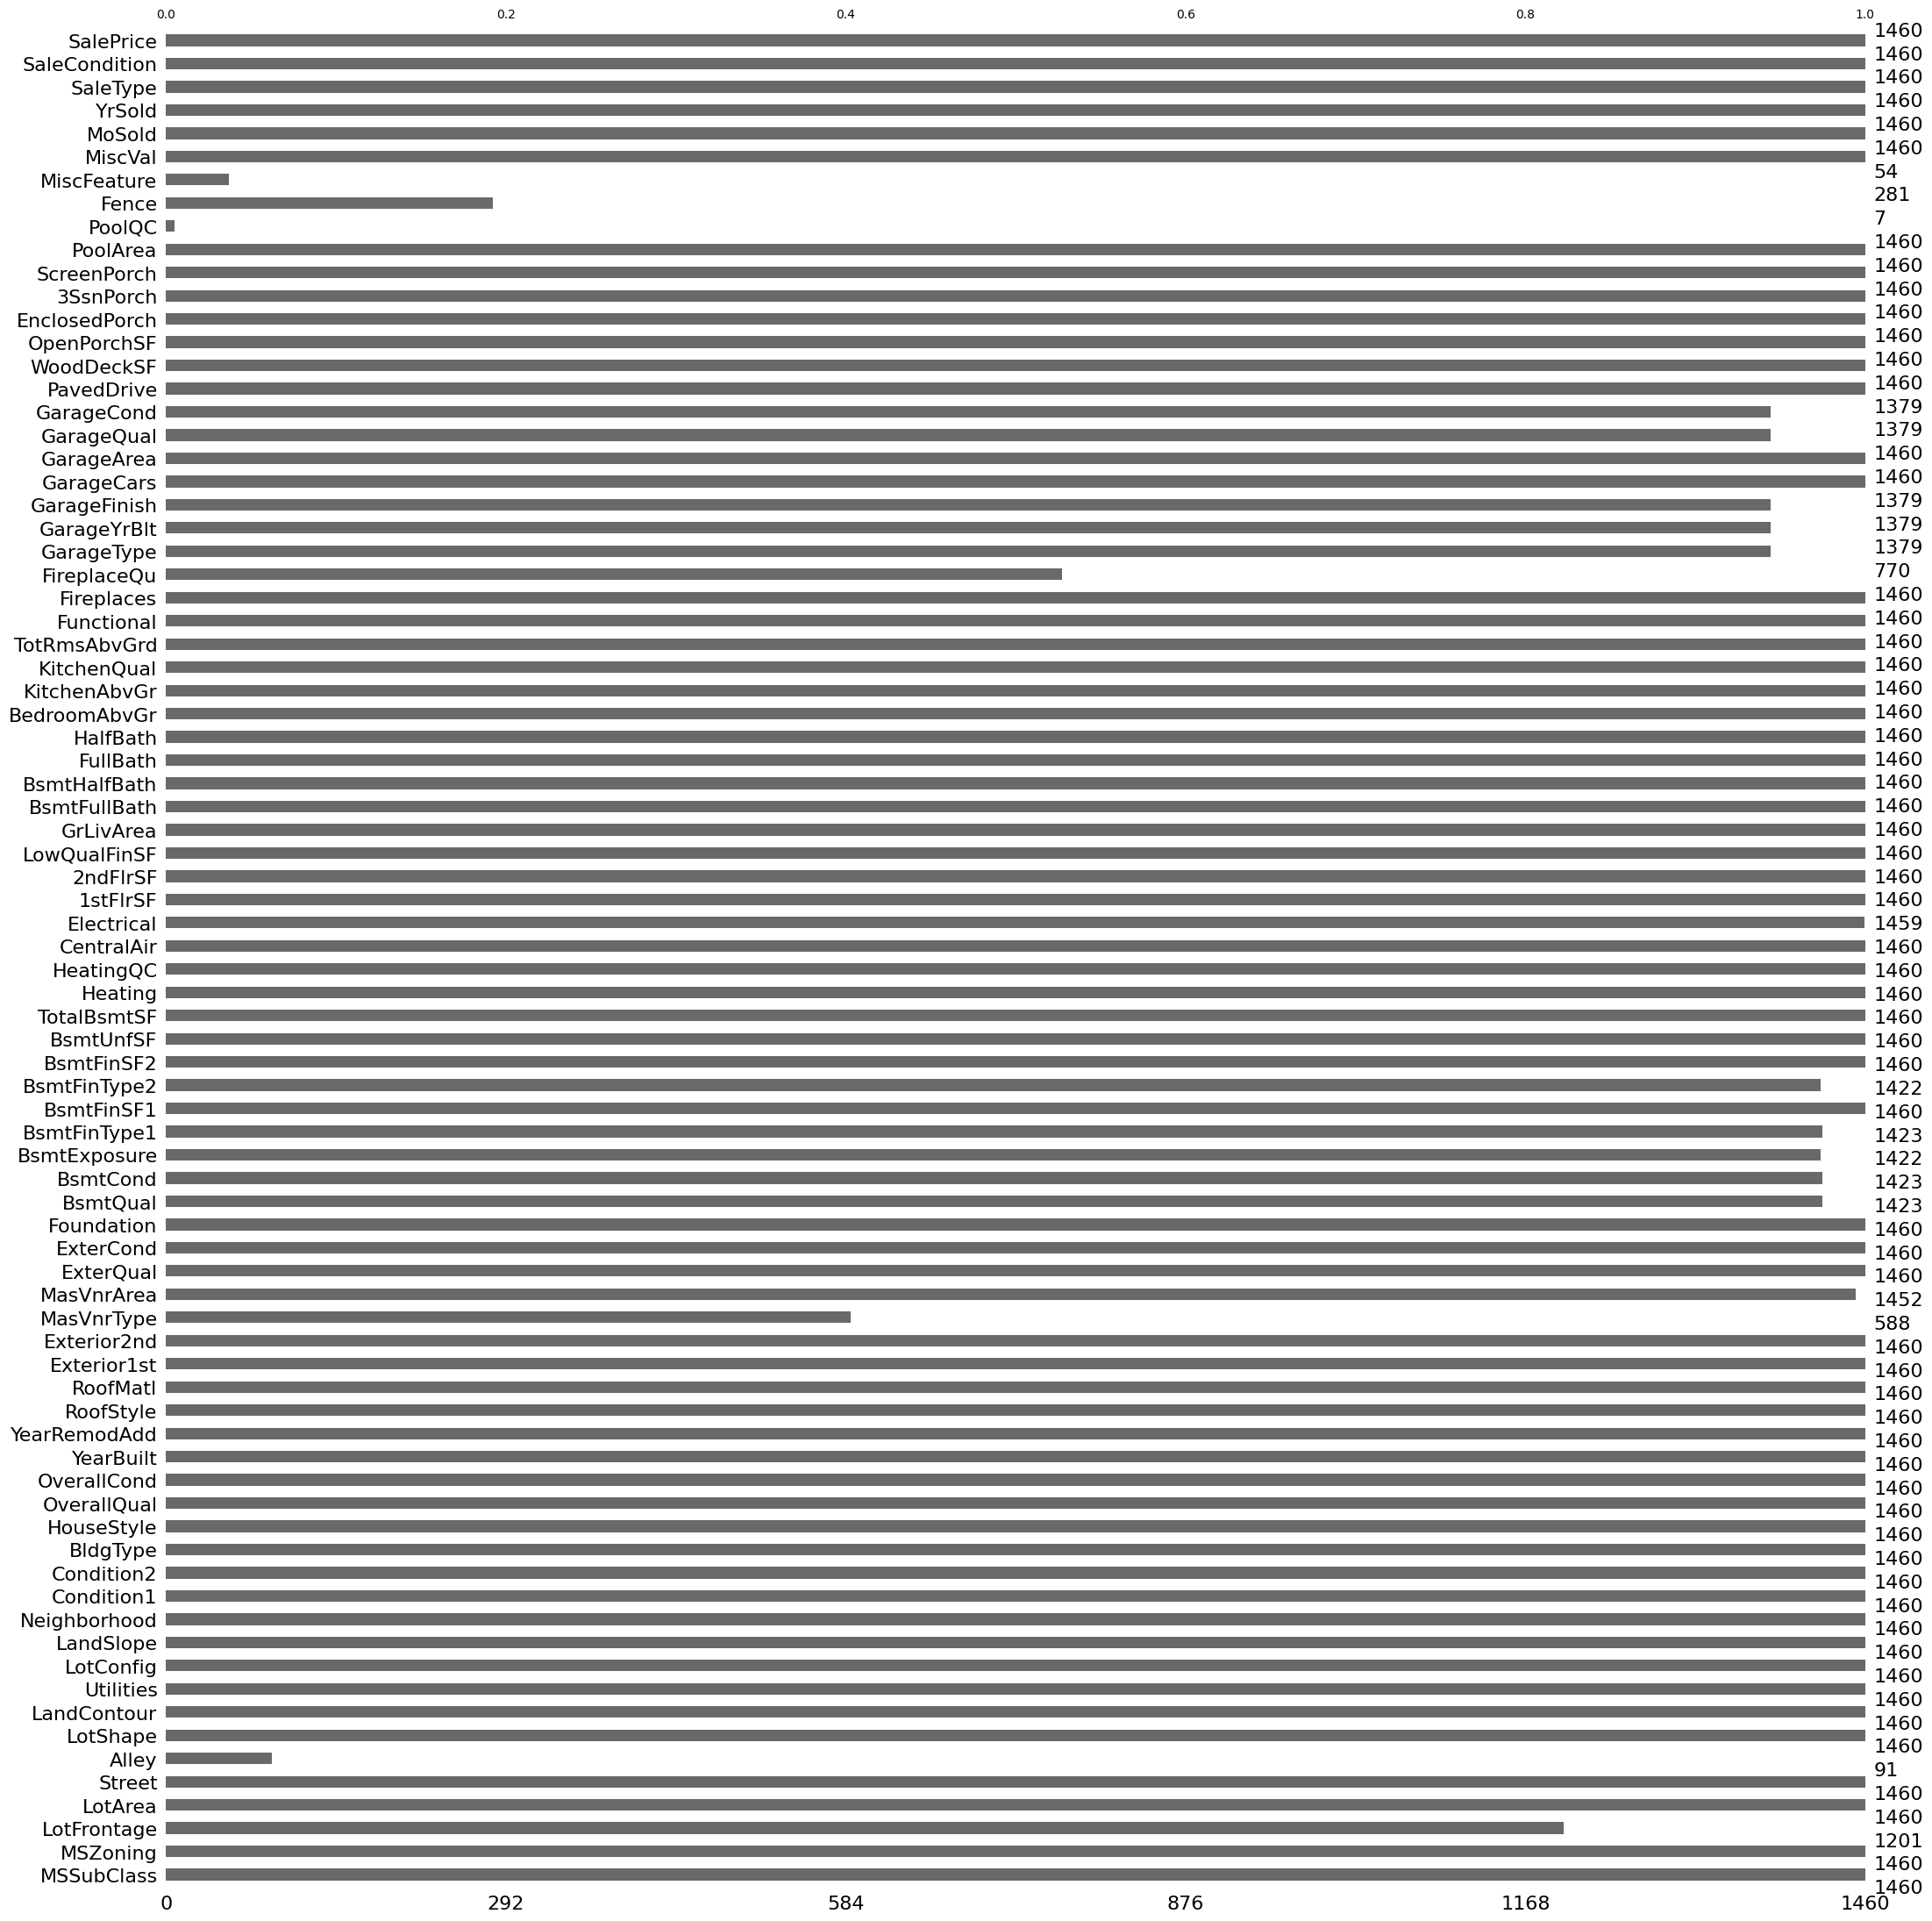

In [42]:
import missingno as msno

msno.bar(df)

In [43]:
missing_values = df.isnull().sum()
missing_percent = (missing_values / len(df)) * 100
missing_df = pd.DataFrame({"Missing Values": missing_values, "Percentage": missing_percent})
print("Missing Values Summary:")
display(missing_df[missing_df["Missing Values"] > 0].sort_values(by="Percentage", ascending=False))

Missing Values Summary:


,Missing Values,Percentage
PoolQC,1453,99.520548
MiscFeature,1406,96.301370
Alley,1369,93.767123
Fence,1179,80.753425
MasVnrType,872,59.726027
FireplaceQu,690,47.260274
LotFrontage,259,17.739726
GarageType,81,5.547945
GarageYrBlt,81,5.547945
GarageFinish,81,5.547945


In [44]:
cols_with_high_missing = missing_df[missing_df["Percentage"] > 50].index.tolist()
print(f"Columns with more than 50% missing values: {cols_with_high_missing}")

Columns with more than 50% missing values: ['Alley', 'MasVnrType', 'PoolQC', 'Fence', 'MiscFeature']


In [45]:
df.drop(columns=cols_with_high_missing, inplace=True)
df.isnull().sum()

MSSubClass         0
MSZoning           0
LotFrontage      259
LotArea            0
Street             0
                ... 
MoSold             0
YrSold             0
SaleType           0
SaleCondition      0
SalePrice          0
Length: 75, dtype: int64

/home/ryz/miniforge3/envs/dsml/lib/python3.10/site-packages/missingno/missingno.py:61: UserWarning: Plotting a sparkline on an existing axis is not currently supported. To remove this warning, set sparkline=False.
  warnings.warn(


<Axes: >

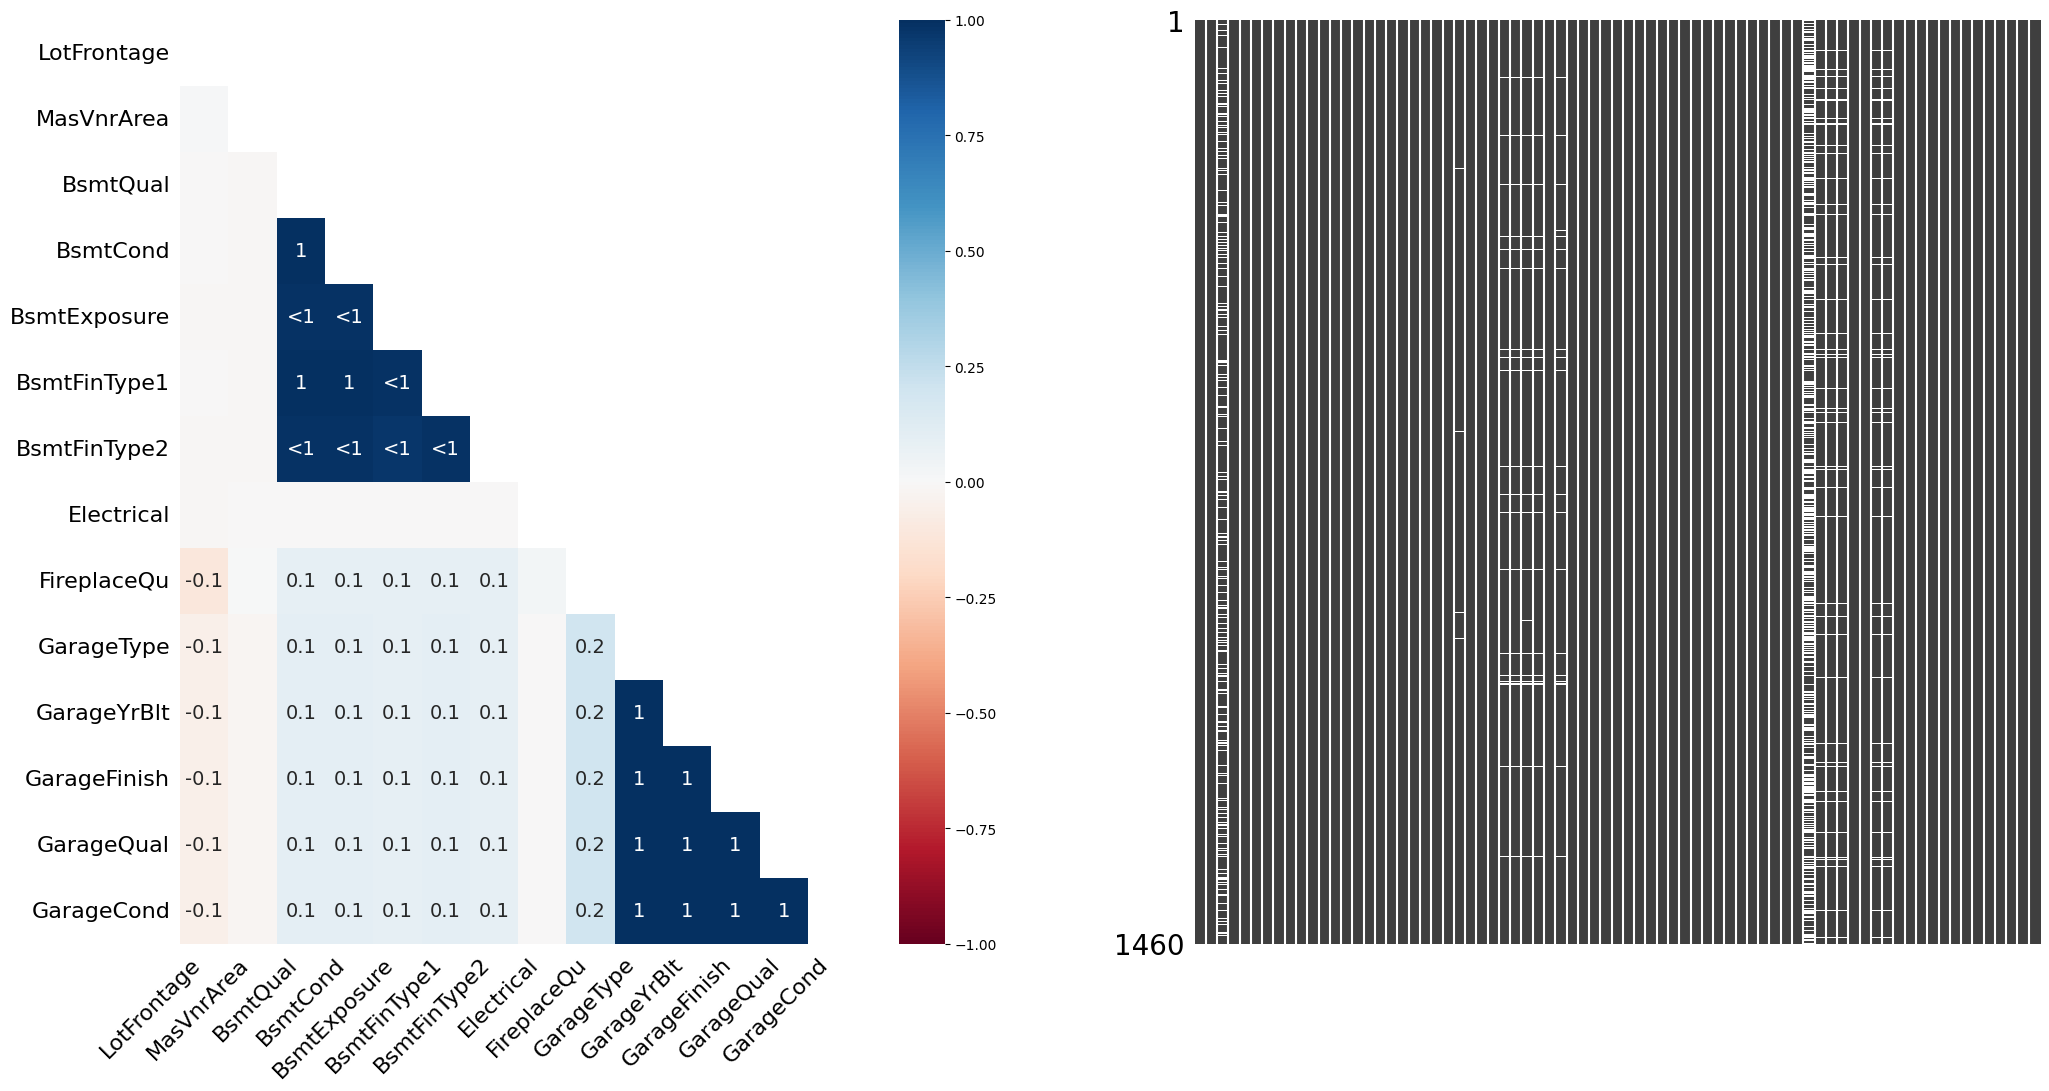

In [46]:
fig,ax = plt.subplots(1,2,figsize=(24,12))
msno.heatmap(df, ax=ax[0])
msno.matrix(df, ax=ax[1])

Missing most likely terjadi secara bersamaan

In [47]:
miss_cols = df.columns[df.isnull().any()].tolist()
for col in miss_cols:
    print(f"\nColumn: {col}, type: {df[col].dtype}, missing values: {df[col].isnull().sum()}")


Column: LotFrontage, type: float64, missing values: 259

Column: MasVnrArea, type: float64, missing values: 8

Column: BsmtQual, type: object, missing values: 37

Column: BsmtCond, type: object, missing values: 37

Column: BsmtExposure, type: object, missing values: 38

Column: BsmtFinType1, type: object, missing values: 37

Column: BsmtFinType2, type: object, missing values: 38

Column: Electrical, type: object, missing values: 1

Column: FireplaceQu, type: object, missing values: 690

Column: GarageType, type: object, missing values: 81

Column: GarageYrBlt, type: float64, missing values: 81

Column: GarageFinish, type: object, missing values: 81

Column: GarageQual, type: object, missing values: 81

Column: GarageCond, type: object, missing values: 81


In [48]:
miss_cat_cols = ['BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', "BsmtQual", "Electrical", "GarageCond", "GarageFinish", "GarageQual", "FireplaceQu", "GarageType"]
df[miss_cat_cols] = df[miss_cat_cols].fillna("None")
df[miss_cat_cols]


,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinType2,BsmtQual,Electrical,GarageCond,GarageFinish,GarageQual,FireplaceQu,GarageType
Id,,,,,,,,,,,
1,TA,No,GLQ,Unf,Gd,SBrkr,TA,RFn,TA,None,Attchd
2,TA,Gd,ALQ,Unf,Gd,SBrkr,TA,RFn,TA,TA,Attchd
3,TA,Mn,GLQ,Unf,Gd,SBrkr,TA,RFn,TA,TA,Attchd
4,Gd,No,ALQ,Unf,TA,SBrkr,TA,Unf,TA,Gd,Detchd
5,TA,Av,GLQ,Unf,Gd,SBrkr,TA,RFn,TA,TA,Attchd
...,...,...,...,...,...,...,...,...,...,...,...
1456,TA,No,Unf,Unf,Gd,SBrkr,TA,RFn,TA,TA,Attchd
1457,TA,No,ALQ,Rec,Gd,SBrkr,TA,Unf,TA,TA,Attchd
1458,Gd,No,GLQ,Unf,TA,SBrkr,TA,RFn,TA,Gd,Attchd


In [49]:
miss_num_cols = ["MasVnrArea", "GarageYrBlt", "LotFrontage"]
df[miss_num_cols] = df[miss_num_cols].fillna(df[miss_num_cols].median())
df.isnull().sum().sort_values(ascending=False)

MSSubClass       0
MSZoning         0
LotFrontage      0
LotArea          0
Street           0
                ..
MoSold           0
YrSold           0
SaleType         0
SaleCondition    0
SalePrice        0
Length: 75, dtype: int64

# Outlier


Target column: SalePrice

Numerical columns: ['MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd', 'Fireplaces', 'GarageYrBlt', 'GarageCars', 'GarageArea', 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea', 'MiscVal', 'MoSold', 'YrSold', 'SalePrice']

Total number of numerical columns: 37


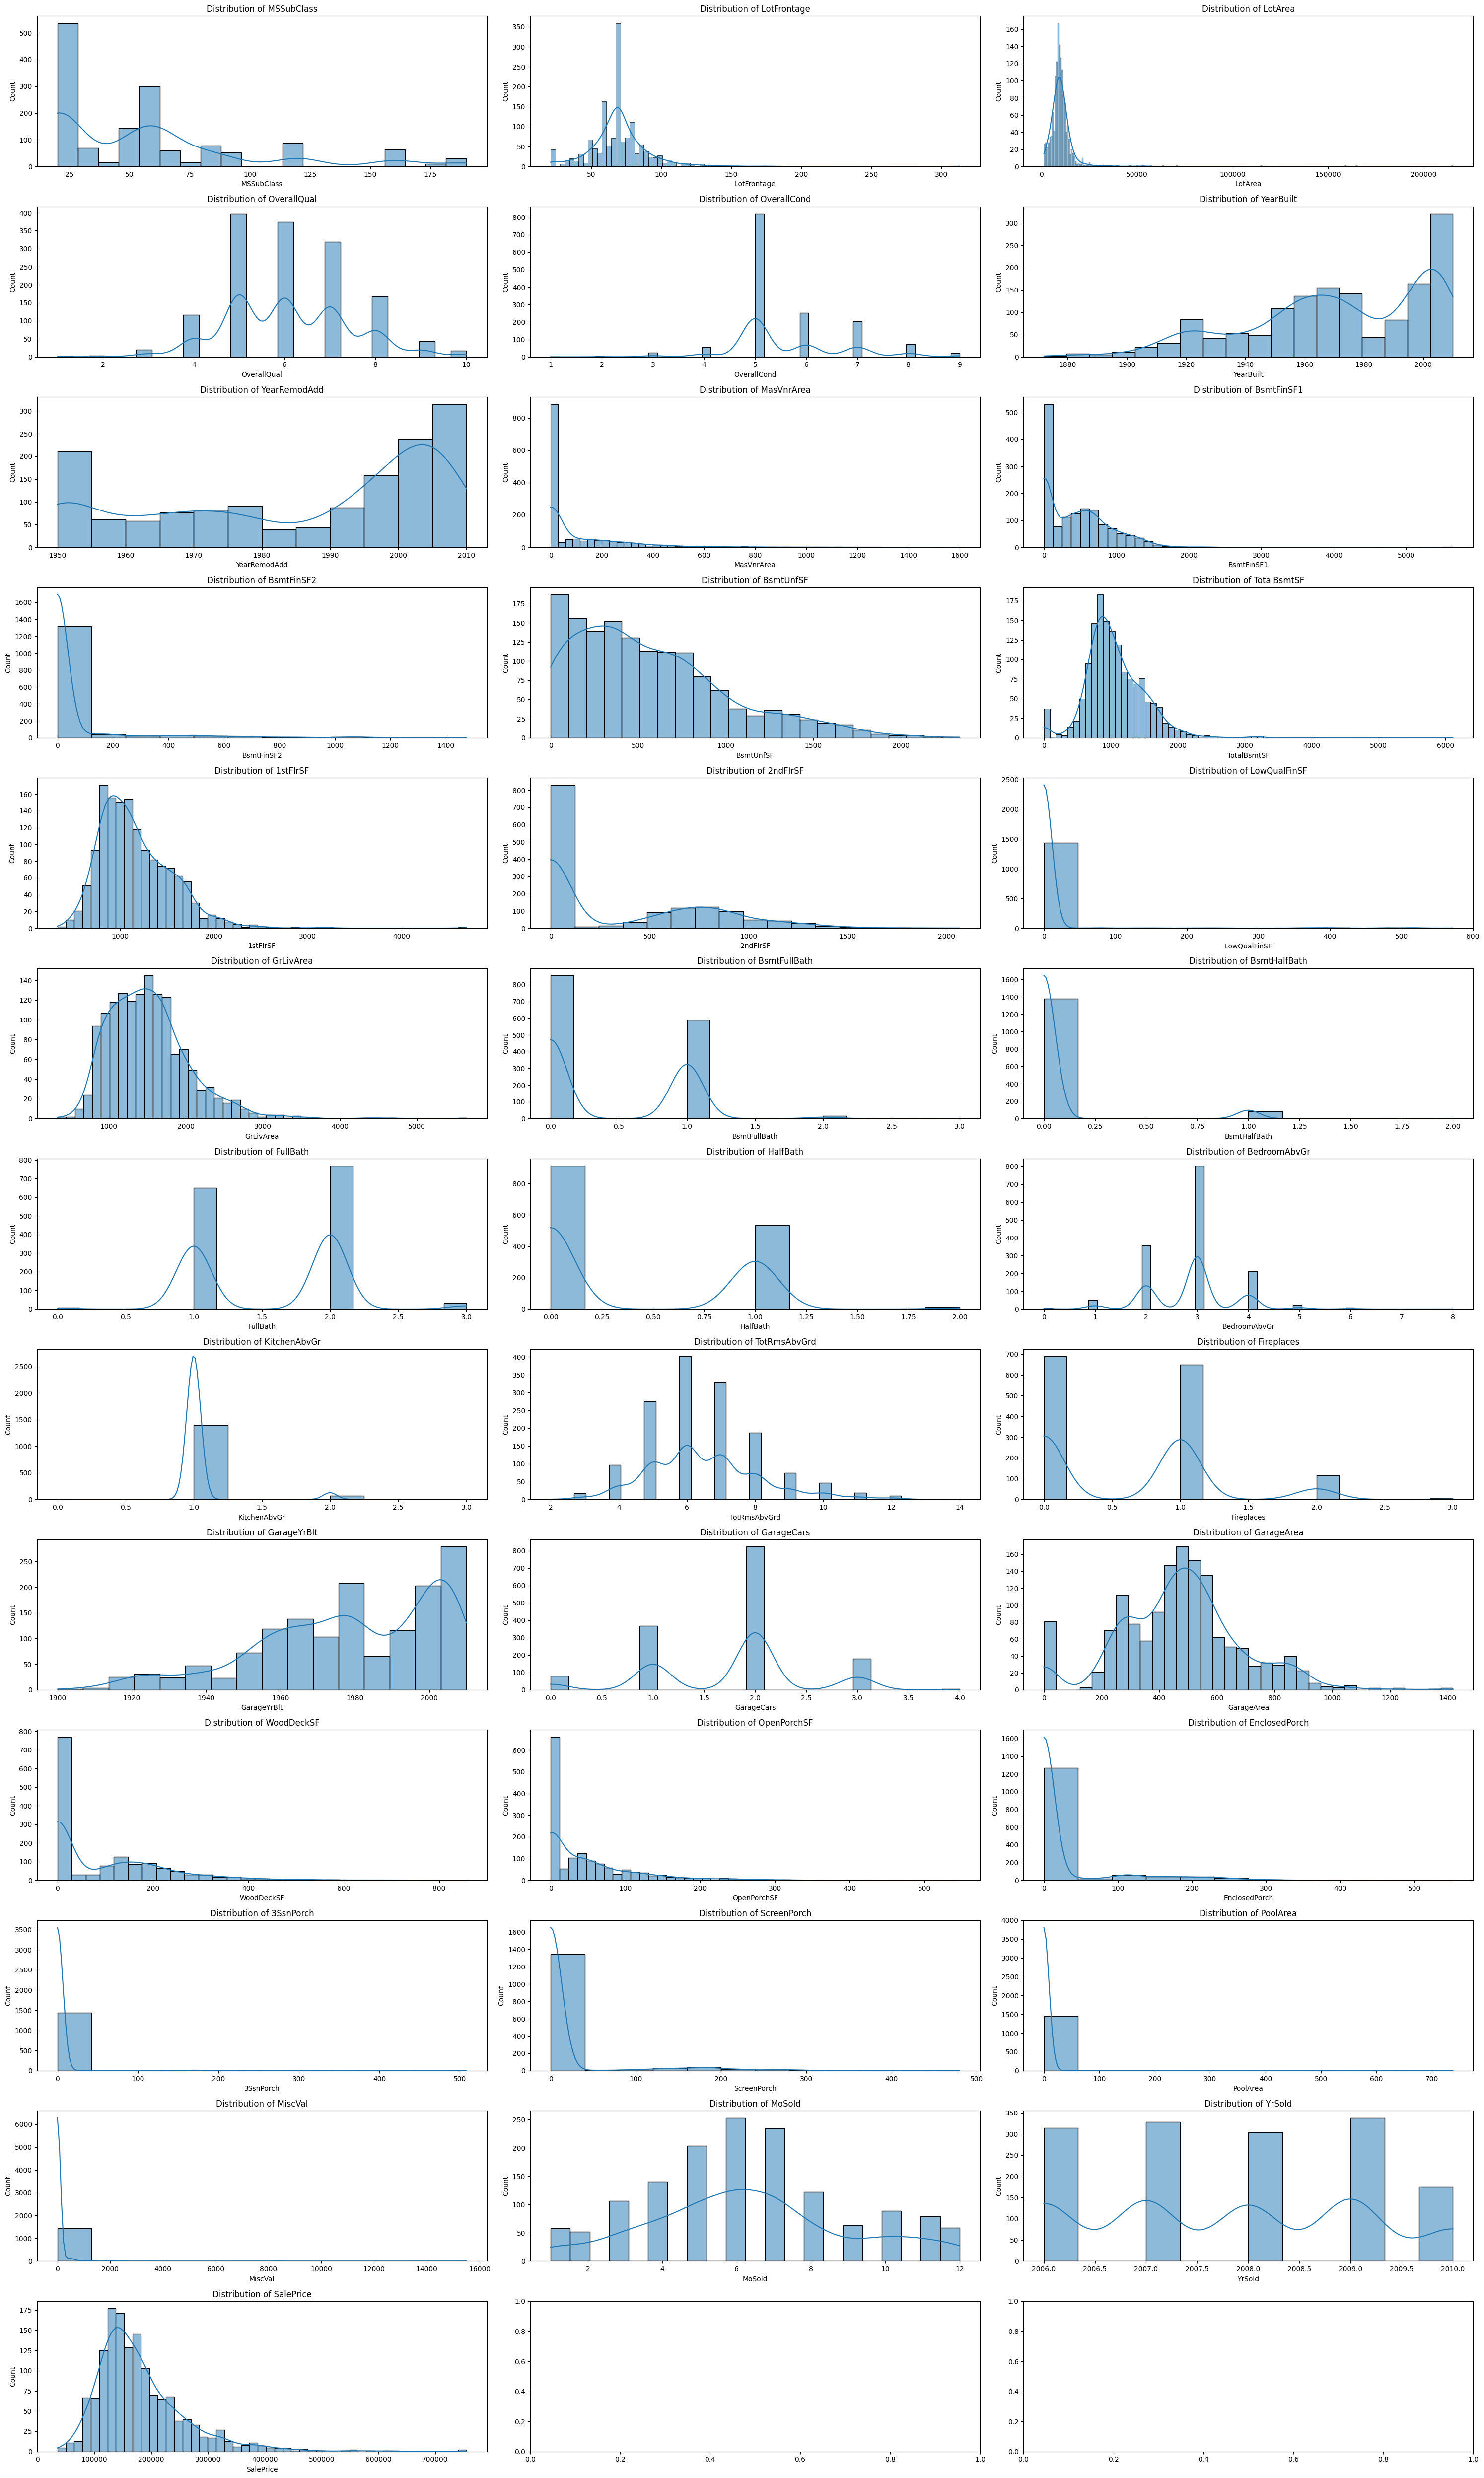

In [50]:
num_cols = df.select_dtypes(include=[int, float]).columns.tolist()
TARGET = "SalePrice"
n = len(num_cols)
print(f"\nTarget column: {TARGET}")

print(f"\nNumerical columns: {num_cols}")
print(f"\nTotal number of numerical columns: {len(num_cols)}")

fig,ax = plt.subplots(n//3+1, 3, figsize=(30,50))
for i, col in enumerate(num_cols):
    sns.histplot(df[col], kde=True, ax=ax[i//3, i%3])
    ax[i//3, i%3].set_title(f"Distribution of {col}")
plt.tight_layout()

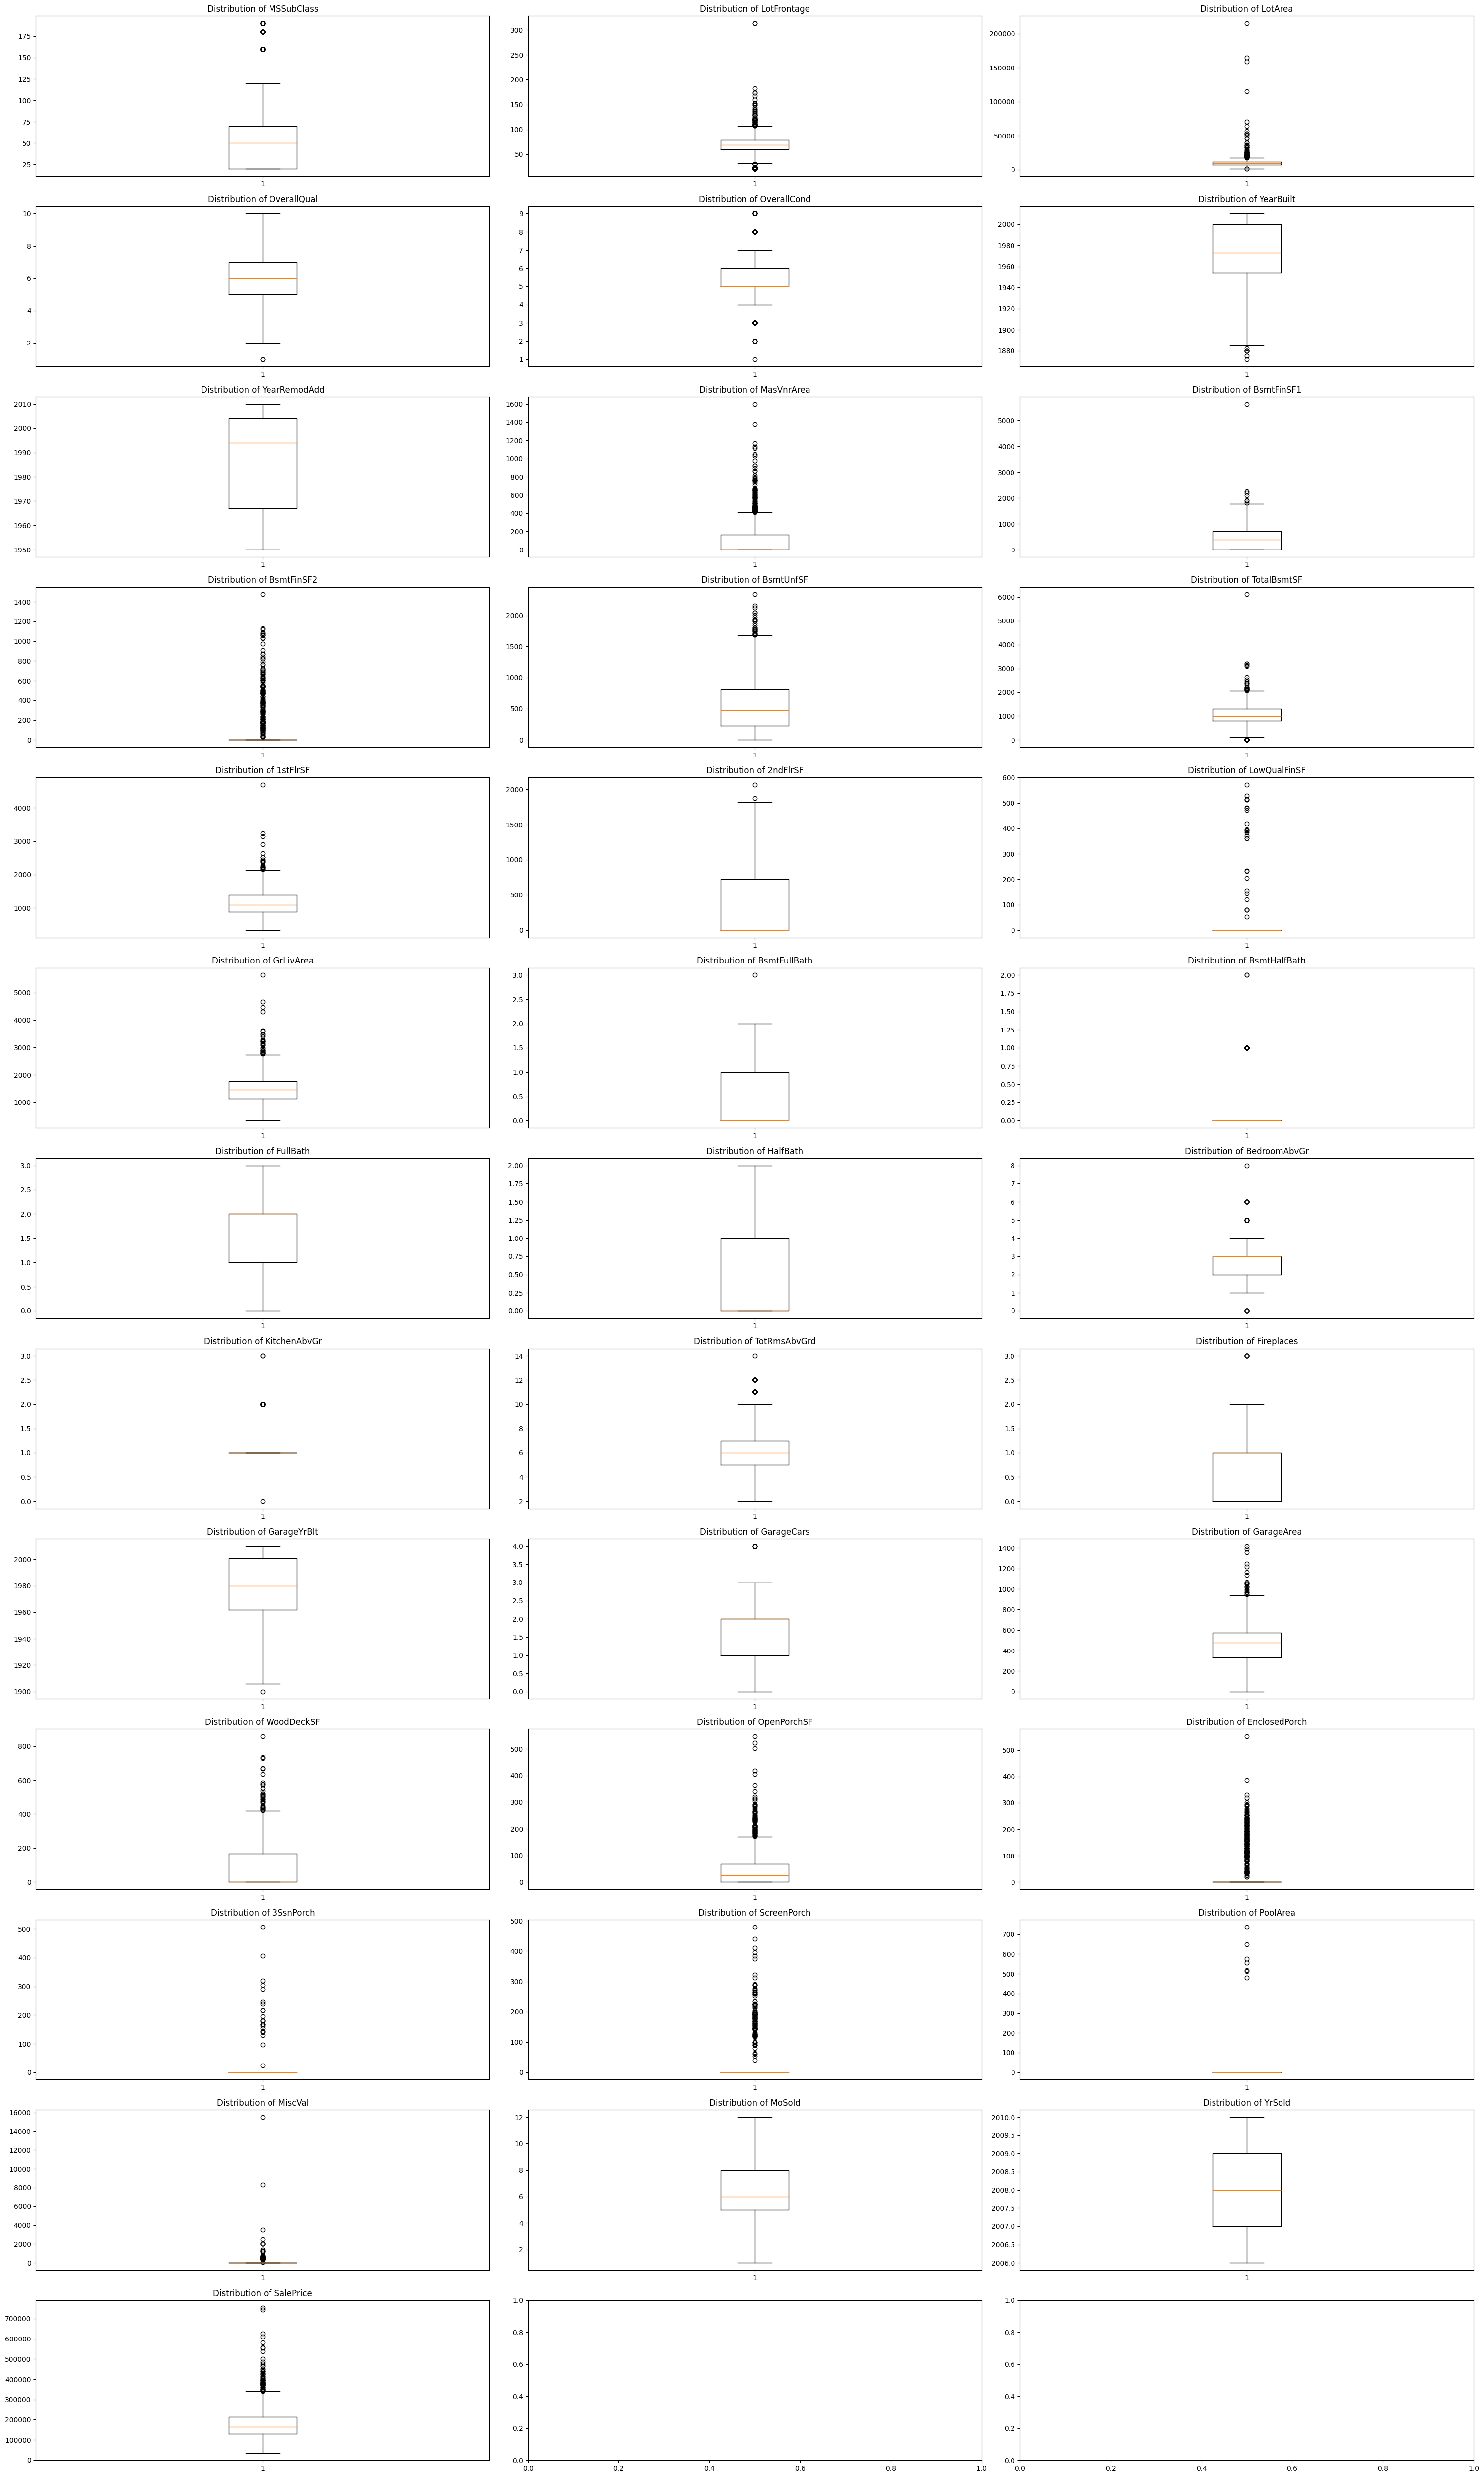

In [51]:
fig,ax = plt.subplots(n//3+1, 3, figsize=(30,50))
for i, col in enumerate(num_cols):
    ax[i//3, i%3].boxplot(df[col])
    ax[i//3, i%3].set_title(f"Distribution of {col}")
plt.tight_layout()

Jika melihat berdasarkan pada pola `domain knowledge` seharusnya disini pola outlier masih terhitung masuk akal karena bisa jadi itu terkait dengan kondisi rumah-rumah mewah. Hal ini masuk akal karena pola outlier juga terlihat mengikuti apa yang terjadi di boxplot `Sales Prices`. Untuk verifikasi, mari kita liat distribusinya

<Axes: >

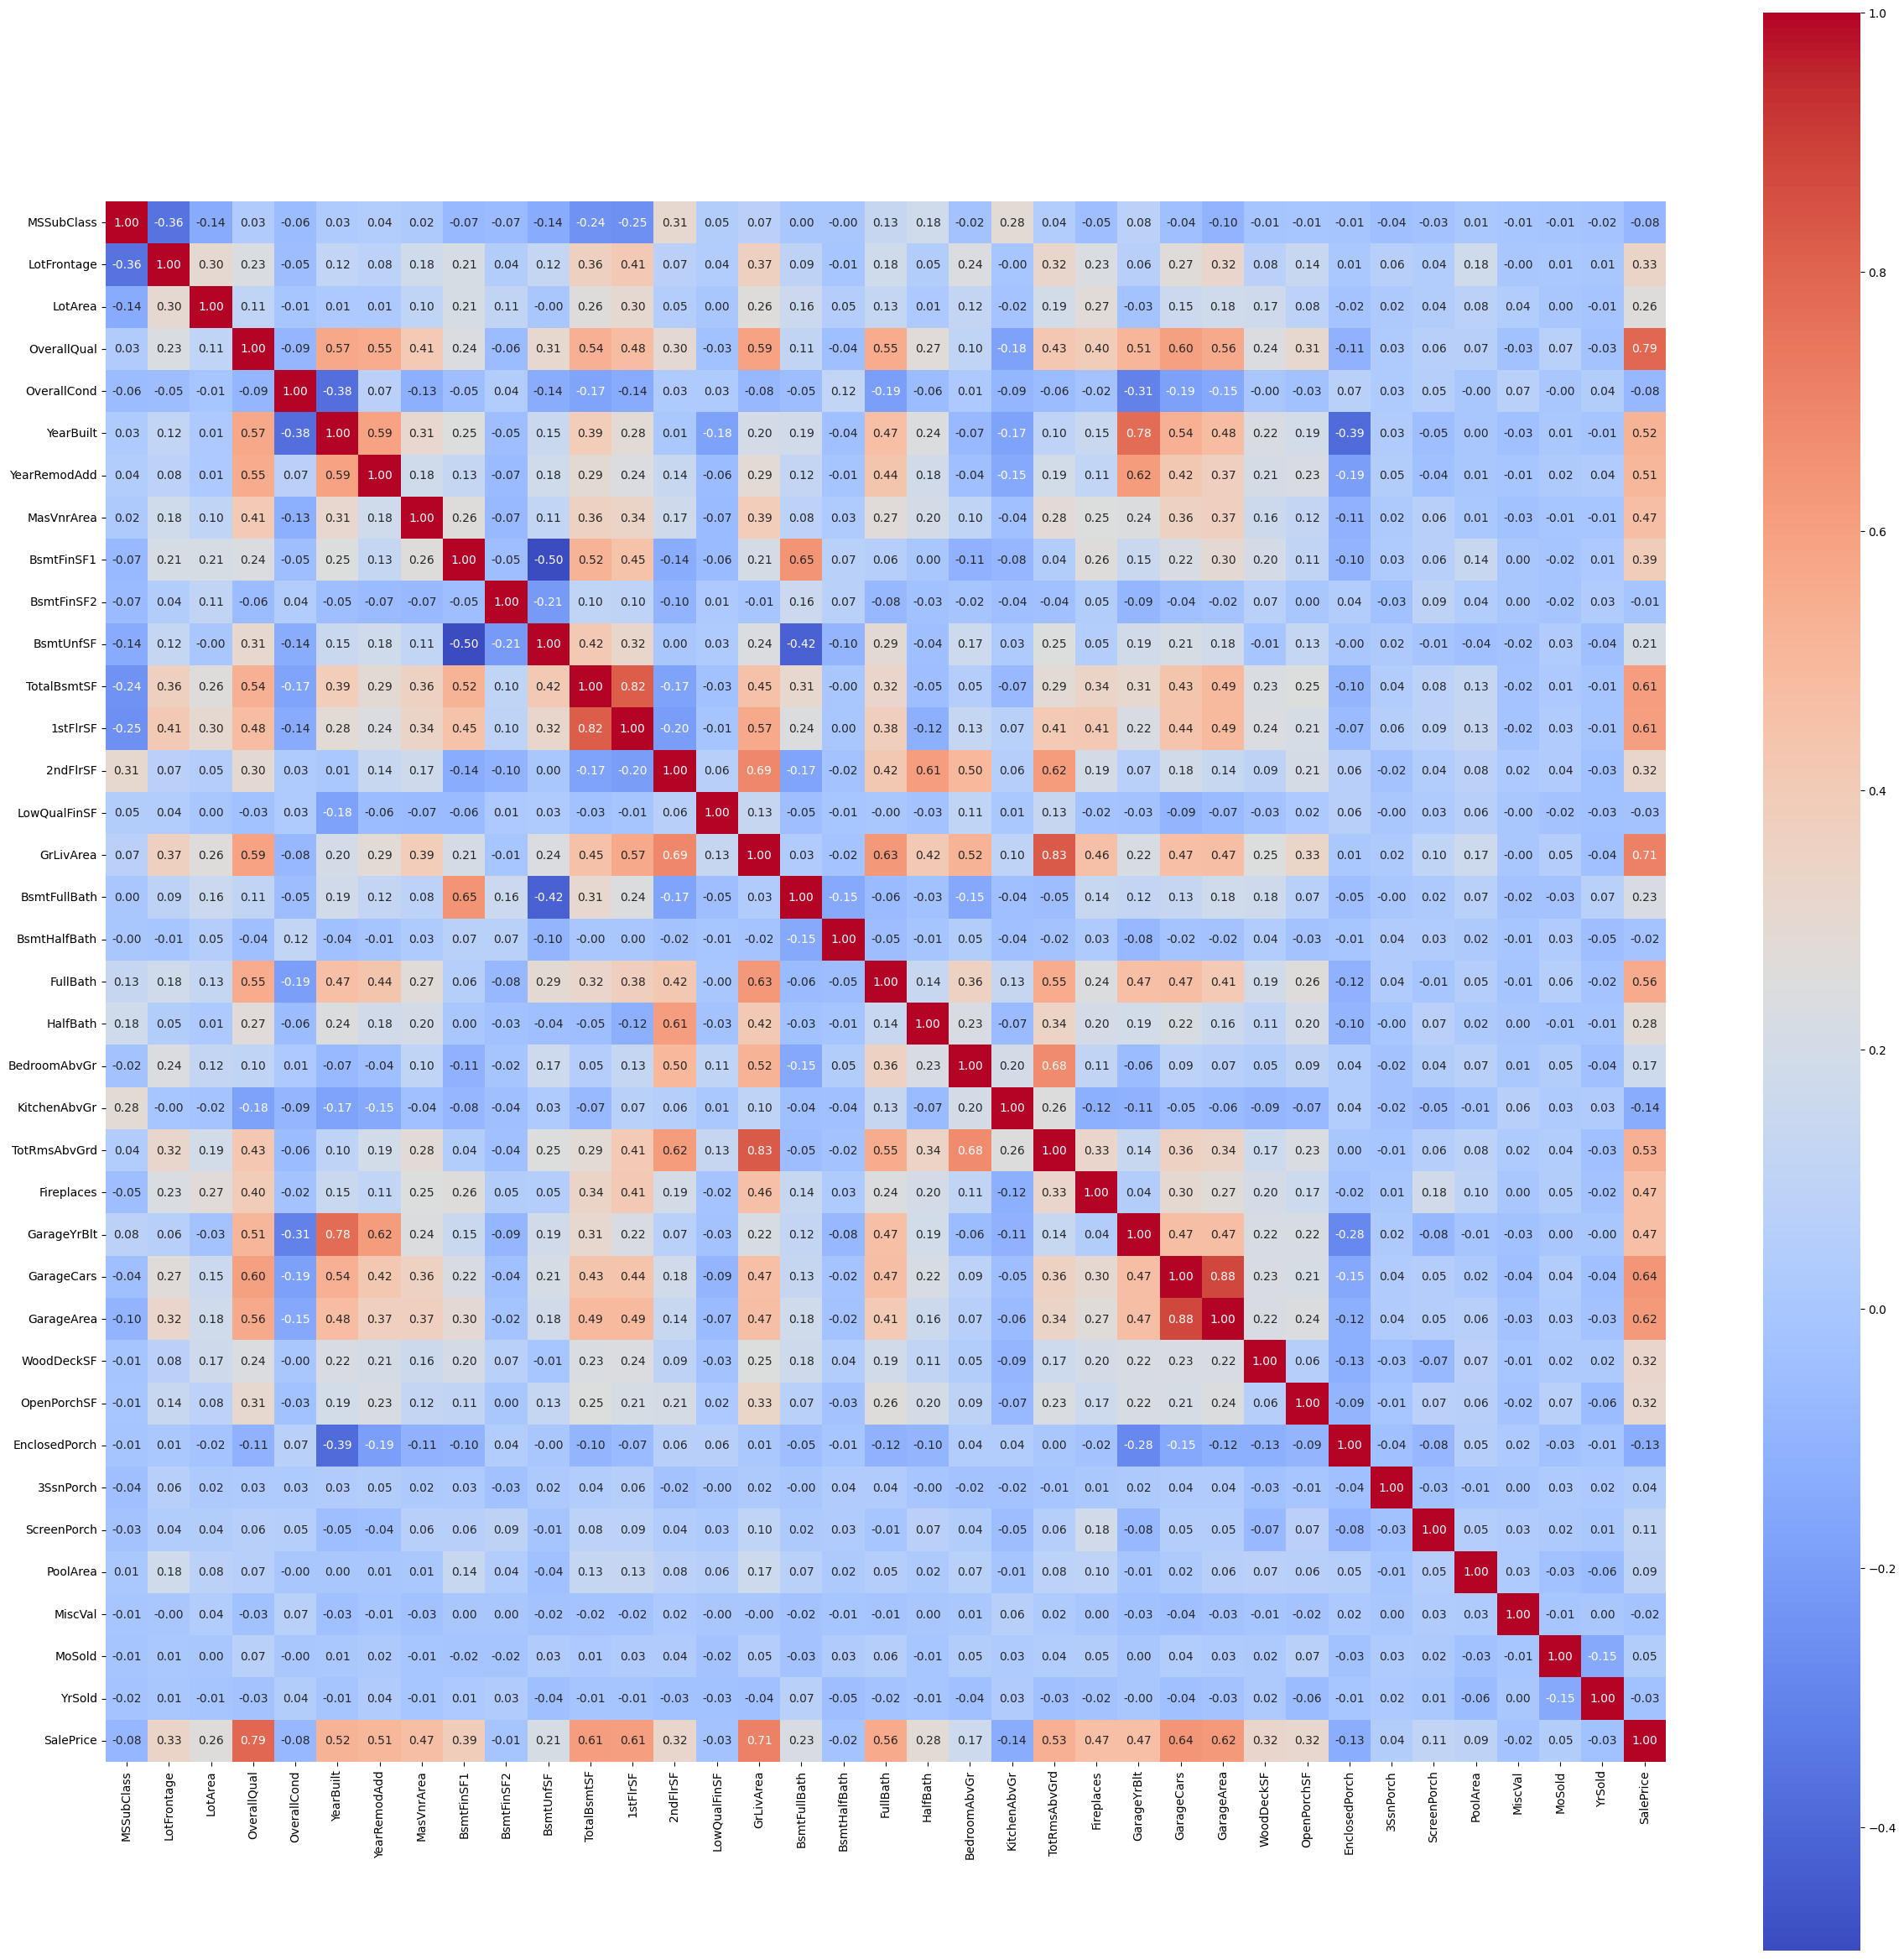

In [52]:
plt.figure(figsize=(30,30))
sns.heatmap(df[num_cols].corr(), annot=True, fmt=".2f", cmap="coolwarm", cbar=True, square=True)

Dapat terlihat disini ternyata lumayan banyak value yang secara bivariat memiliki korelasi yang cukup tinggi dengan sales price. Mari kita bandingkan skewness dengan korelasi terhadap `SalePrice`

In [53]:
corr_with_target = df[num_cols].corr()[TARGET].sort_values(ascending=False)
print(f"\nCorrelation of numerical columns with target column '{TARGET}':")
print(corr_with_target)

skew_with_corr_target = df[num_cols].skew().sort_values(ascending=False)
skew_with_corr = pd.DataFrame({'Skewness': skew_with_corr_target, 'Correlation with Target': corr_with_target})
print(f"\nSkewness of numerical columns:")
display(skew_with_corr.sort_values(by='Skewness', ascending=False))


Correlation of numerical columns with target column 'SalePrice':
SalePrice        1.000000
OverallQual      0.790982
GrLivArea        0.708624
GarageCars       0.640409
GarageArea       0.623431
TotalBsmtSF      0.613581
1stFlrSF         0.605852
FullBath         0.560664
TotRmsAbvGrd     0.533723
YearBuilt        0.522897
YearRemodAdd     0.507101
MasVnrArea       0.472614
Fireplaces       0.466929
GarageYrBlt      0.466754
BsmtFinSF1       0.386420
LotFrontage      0.334771
WoodDeckSF       0.324413
2ndFlrSF         0.319334
OpenPorchSF      0.315856
HalfBath         0.284108
LotArea          0.263843
BsmtFullBath     0.227122
BsmtUnfSF        0.214479
BedroomAbvGr     0.168213
ScreenPorch      0.111447
PoolArea         0.092404
MoSold           0.046432
3SsnPorch        0.044584
BsmtFinSF2      -0.011378
BsmtHalfBath    -0.016844
MiscVal         -0.021190
LowQualFinSF    -0.025606
YrSold          -0.028923
OverallCond     -0.077856
MSSubClass      -0.084284
EnclosedPorch   -0.12857

,Skewness,Correlation with Target
MiscVal,24.476794,-0.021190
PoolArea,14.828374,0.092404
LotArea,12.207688,0.263843
3SsnPorch,10.304342,0.044584
LowQualFinSF,9.011341,-0.025606
KitchenAbvGr,4.488397,-0.135907
BsmtFinSF2,4.255261,-0.011378
ScreenPorch,4.122214,0.111447
BsmtHalfBath,4.103403,-0.016844
EnclosedPorch,3.089872,-0.128578


Ternyata feature dengan high skewness (>3) malah cenderung tidak berkorelasi dengan Target. Maka dari itu, bisa jadi value tersebut adalah outlier. Preprocessing yang bisa dilakukan adalah dengan mencoba untuk melakukan `log transform`

In [54]:
cols_with_high_skewness = skew_with_corr[skew_with_corr['Skewness'].abs() > 3].index.tolist()
print(f"\nColumns with high skewness (absolute skewness > 3): {cols_with_high_skewness}")

print(f"Value range of columns with high skewness:")
for col in cols_with_high_skewness:
    print(f"  {col}: {df[col].min()} to {df[col].max()}") # No minus, log scale sudah cukup tidak perlu yeo-johnson

df[cols_with_high_skewness].clip(lower=df[cols_with_high_skewness].quantile(0.01), upper=df[cols_with_high_skewness].quantile(0.99), inplace=True, axis=1) # Clip values to be non-negative for log transformation
df[cols_with_high_skewness] = np.log1p(df[cols_with_high_skewness])

skew_with_corr_target = df[num_cols].skew().sort_values(ascending=False)
skew_with_corr = pd.DataFrame({'Skewness': skew_with_corr_target, 'Correlation with Target': corr_with_target})
print(f"\nSkewness of numerical columns:")
display(skew_with_corr.sort_values(by='Skewness', ascending=False))


Columns with high skewness (absolute skewness > 3): ['3SsnPorch', 'BsmtFinSF2', 'BsmtHalfBath', 'EnclosedPorch', 'KitchenAbvGr', 'LotArea', 'LowQualFinSF', 'MiscVal', 'PoolArea', 'ScreenPorch']
Value range of columns with high skewness:
  3SsnPorch: 0 to 508
  BsmtFinSF2: 0 to 1474
  BsmtHalfBath: 0 to 2
  EnclosedPorch: 0 to 552
  KitchenAbvGr: 0 to 3
  LotArea: 1300 to 215245
  LowQualFinSF: 0 to 572
  MiscVal: 0 to 15500
  PoolArea: 0 to 738
  ScreenPorch: 0 to 480

Skewness of numerical columns:


/tmp/ipykernel_233172/2659043465.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[cols_with_high_skewness].clip(lower=df[cols_with_high_skewness].quantile(0.01), upper=df[cols_with_high_skewness].quantile(0.99), inplace=True, axis=1) # Clip values to be non-negative for log transformation
/tmp/ipykernel_233172/2659043465.py:8: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[[830.38]
 [830.38]
 [830.38]
 [830.38]
 [830.38]
 [830.38]
 [830.38]
 [830.38]
 [830.38]
 [830.38]
 [830.38]
 [830.38]
 [830.38]
 [830.38]
 [830.38]]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df[cols_with_high_skewness].clip(lower=df[cols_with_high_skewness].quantile(0.01), upper=df[cols_with_high_s

,Skewness,Correlation with Target
PoolArea,14.363102,0.092404
3SsnPorch,7.734975,0.044584
LowQualFinSF,7.460317,-0.025606
MiscVal,5.170704,-0.021190
BsmtHalfBath,3.933064,-0.016844
KitchenAbvGr,3.869414,-0.135907
ScreenPorch,3.150409,0.111447
MasVnrArea,2.677616,0.472614
BsmtFinSF2,2.523694,-0.011378
LotFrontage,2.409147,0.334771


Oke sepertinya sudah cukup oke, meskipun masih cukup high skewness

# Data Transformation

In [55]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaled_features = scaler.fit_transform(df[num_cols])
scaled_df = pd.DataFrame(scaled_features, columns=num_cols, index=df.index)

df = pd.concat([scaled_df, df.drop(columns=num_cols)], axis=1)
df.head()

,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,...,KitchenQual,Functional,FireplaceQu,GarageType,GarageFinish,GarageQual,GarageCond,PavedDrive,SaleType,SaleCondition
Id,,,,,,,,,,,,,,,,,,,,,
1,0.073375,-0.220875,-0.133270,0.651479,-0.517200,1.050994,0.878668,0.514104,0.575425,-0.355342,...,Gd,Typ,None,Attchd,RFn,TA,TA,Y,WD,Normal
2,-0.872563,0.460320,0.113413,-0.071836,2.179628,0.156734,-0.429577,-0.570750,1.171992,-0.355342,...,TA,Typ,TA,Attchd,RFn,TA,TA,Y,WD,Normal
3,0.073375,-0.084636,0.420049,0.651479,-0.517200,0.984752,0.830215,0.325915,0.092907,-0.355342,...,Gd,Typ,TA,Attchd,RFn,TA,TA,Y,WD,Normal
4,0.309859,-0.447940,0.103317,0.651479,-0.517200,-1.863632,-0.720298,-0.570750,-0.499274,-0.355342,...,Gd,Typ,Gd,Detchd,Unf,TA,TA,Y,WD,Abnorml
5,0.073375,0.641972,0.878431,1.374795,-0.517200,0.951632,0.733308,1.366489,0.463568,-0.355342,...,Gd,Typ,TA,Attchd,RFn,TA,TA,Y,WD,Normal


In [56]:
cat_cols = df.select_dtypes(include=[object]).columns.tolist()

cardinality = df[cat_cols].nunique().sort_values(ascending=False)
print(f"\nCardinality of categorical columns:")
display(cardinality) # Kolom yang memiliki cardinality tinggi mungkin akan memerlukan teknik encoding yang berbeda, seperti target encoding 


cat_cols_with_high_cardinality = cardinality[cardinality > 10].index.tolist()
print(f"\nCategorical columns with high cardinality (more than 10 unique values): {cat_cols_with_high_cardinality}")

cat_cols_with_low_cardinality = cardinality[cardinality <= 10].index.tolist()
print(f"\nCategorical columns with low cardinality (10 or fewer unique values): {cat_cols_with_low_cardinality}")


Cardinality of categorical columns:


Neighborhood     25
Exterior2nd      16
Exterior1st      15
Condition1        9
SaleType          9
RoofMatl          8
Condition2        8
HouseStyle        8
BsmtFinType2      7
Functional        7
BsmtFinType1      7
GarageType        7
Foundation        6
Electrical        6
SaleCondition     6
GarageCond        6
FireplaceQu       6
Heating           6
GarageQual        6
RoofStyle         6
LotConfig         5
MSZoning          5
BsmtQual          5
HeatingQC         5
BldgType          5
BsmtExposure      5
ExterCond         5
BsmtCond          5
LotShape          4
LandContour       4
KitchenQual       4
ExterQual         4
GarageFinish      4
LandSlope         3
PavedDrive        3
Street            2
Utilities         2
CentralAir        2
dtype: int64


Categorical columns with high cardinality (more than 10 unique values): ['Neighborhood', 'Exterior2nd', 'Exterior1st']

Categorical columns with low cardinality (10 or fewer unique values): ['Condition1', 'SaleType', 'RoofMatl', 'Condition2', 'HouseStyle', 'BsmtFinType2', 'Functional', 'BsmtFinType1', 'GarageType', 'Foundation', 'Electrical', 'SaleCondition', 'GarageCond', 'FireplaceQu', 'Heating', 'GarageQual', 'RoofStyle', 'LotConfig', 'MSZoning', 'BsmtQual', 'HeatingQC', 'BldgType', 'BsmtExposure', 'ExterCond', 'BsmtCond', 'LotShape', 'LandContour', 'KitchenQual', 'ExterQual', 'GarageFinish', 'LandSlope', 'PavedDrive', 'Street', 'Utilities', 'CentralAir']


## One Hot Encoding

In [57]:
df = pd.concat([df.drop(columns=cat_cols_with_low_cardinality), pd.get_dummies(df[cat_cols_with_low_cardinality], drop_first=True)], axis=1)
df

,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,...,GarageFinish_None,GarageFinish_RFn,GarageFinish_Unf,LandSlope_Mod,LandSlope_Sev,PavedDrive_P,PavedDrive_Y,Street_Pave,Utilities_NoSeWa,CentralAir_Y
Id,,,,,,,,,,,,,,,,,,,,,
1,0.073375,-0.220875,-0.133270,0.651479,-0.517200,1.050994,0.878668,0.514104,0.575425,-0.355342,...,False,True,False,False,False,False,True,True,False,True
2,-0.872563,0.460320,0.113413,-0.071836,2.179628,0.156734,-0.429577,-0.570750,1.171992,-0.355342,...,False,True,False,False,False,False,True,True,False,True
3,0.073375,-0.084636,0.420049,0.651479,-0.517200,0.984752,0.830215,0.325915,0.092907,-0.355342,...,False,True,False,False,False,False,True,True,False,True
4,0.309859,-0.447940,0.103317,0.651479,-0.517200,-1.863632,-0.720298,-0.570750,-0.499274,-0.355342,...,False,False,True,False,False,False,True,True,False,True
5,0.073375,0.641972,0.878431,1.374795,-0.517200,0.951632,0.733308,1.366489,0.463568,-0.355342,...,False,True,False,False,False,False,True,True,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1456,0.073375,-0.357114,-0.259231,-0.071836,-0.517200,0.918511,0.733308,-0.570750,-0.973018,-0.355342,...,False,True,False,False,False,False,True,True,False,True
1457,-0.872563,0.687385,0.725429,-0.071836,0.381743,0.222975,0.151865,0.087911,0.759659,2.409693,...,False,False,True,False,False,False,True,True,False,True
1458,0.309859,-0.175462,-0.002359,0.651479,3.078570,-1.002492,1.024029,-0.570750,-0.369871,-0.355342,...,False,True,False,False,False,False,True,True,False,True


## Target Encoding

In [58]:
from category_encoders import TargetEncoder
te = TargetEncoder()
encoded = te.fit_transform(
    df[cat_cols_with_high_cardinality],
    df[TARGET]
)

encoded = pd.DataFrame(
    encoded,
    columns=cat_cols_with_high_cardinality,
    index=df.index
)

df[cat_cols_with_high_cardinality] = encoded

print(f"\nDataframe shape after encoding: {df.shape}")
df.head()



Dataframe shape after encoding: (1460, 195)


,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,...,GarageFinish_None,GarageFinish_RFn,GarageFinish_Unf,LandSlope_Mod,LandSlope_Sev,PavedDrive_P,PavedDrive_Y,Street_Pave,Utilities_NoSeWa,CentralAir_Y
Id,,,,,,,,,,,,,,,,,,,,,
1,0.073375,-0.220875,-0.133270,0.651479,-0.517200,1.050994,0.878668,0.514104,0.575425,-0.355342,...,False,True,False,False,False,False,True,True,False,True
2,-0.872563,0.460320,0.113413,-0.071836,2.179628,0.156734,-0.429577,-0.570750,1.171992,-0.355342,...,False,True,False,False,False,False,True,True,False,True
3,0.073375,-0.084636,0.420049,0.651479,-0.517200,0.984752,0.830215,0.325915,0.092907,-0.355342,...,False,True,False,False,False,False,True,True,False,True
4,0.309859,-0.447940,0.103317,0.651479,-0.517200,-1.863632,-0.720298,-0.570750,-0.499274,-0.355342,...,False,False,True,False,False,False,True,True,False,True
5,0.073375,0.641972,0.878431,1.374795,-0.517200,0.951632,0.733308,1.366489,0.463568,-0.355342,...,False,True,False,False,False,False,True,True,False,True


# Save

In [59]:
df.to_csv("5054251001_Benedictus Ryu Gunawan_Tugas_Praproses_Data.csv", index=False) # Tasknya hanya sampai untuk preprocessing data

# PCA Dimensionality Reduction

In [60]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

X = df.drop(columns=[TARGET])

# hanya kolom numerik
X = X.select_dtypes(include=np.number)
X = X.replace([np.inf, -np.inf], np.nan)
X = X.dropna()

vif_data = pd.DataFrame()
vif_data["feature"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
vif_data = vif_data.sort_values(by="VIF", ascending=False)
print(f"\nVariance Inflation Factor (VIF) for numerical features:")
display(vif_data)


Variance Inflation Factor (VIF) for numerical features:


,feature,VIF
15,GrLivArea,1059.503626
13,2ndFlrSF,730.820370
12,1stFlrSF,573.704068
11,TotalBsmtSF,36.879792
8,BsmtFinSF1,35.996720
10,BsmtUnfSF,35.276149
38,Exterior2nd,11.085607
37,Exterior1st,10.426032
14,LowQualFinSF,8.971605
5,YearBuilt,5.651614


In [61]:
high_vif_features = vif_data[vif_data["VIF"] > 10]["feature"].tolist()
print(f"\nFeatures with high VIF (greater than 10): {high_vif_features}")


Features with high VIF (greater than 10): ['GrLivArea', '2ndFlrSF', '1stFlrSF', 'TotalBsmtSF', 'BsmtFinSF1', 'BsmtUnfSF', 'Exterior2nd', 'Exterior1st']


### Penanganan High-VIF dengan PCA (High-VIF → PCA)

VIF mengukur seberapa besar varians koefisien regresi membengkak akibat kolinearitas antar prediktor:

$$
VIF_j = \frac{1}{1 - R_j^2}
$$

Threshold yang dipakai di notebook ini (sel sebelumnya): **VIF > 10 = high-VIF** — sesuai output di atas ada **21 fitur** (`YrSold`, `YearRemodAdd`, `YearBuilt`, `GrLivArea`, `1stFlrSF`, ...). Nilai ekstrem (mis. `YrSold` ≈ 28000) menandakan kolinearitas nyaris sempurna, sehingga regresi linear menjadi tidak stabil.

PCA mengatasi ini dengan mengubah fitur-fitur berkorelasi menjadi komponen baru yang **ortogonal (tidak berkorelasi)**:

$$
Z = X_{scaled} W
$$

Alur di bawah:
1. Visualisasi VIF & konfirmasi daftar `high_vif_features`.
2. Standardisasi fitur high-VIF (wajib — PCA sensitif terhadap skala, mis. `LotArea` ribuan vs `OverallQual` 1–10).
3. Fit PCA penuh → scree plot + cumulative variance → pilih $k$ (mis. ≥ 90%).
4. Transform ke $k$ PC → **gabungkan**: buang 21 kolom high-VIF, tempel skor PC, pertahankan kolom low-VIF + hasil encoding + `SalePrice`.
5. Validasi: VIF sesudah ≈ 1.0 dan korelasi antar-PC ≈ 0.


Threshold VIF      : > 10
Jumlah high-VIF    : 8 fitur
High-VIF           : ['Exterior1st', 'Exterior2nd', 'BsmtUnfSF', 'BsmtFinSF1', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'GrLivArea']
Low-VIF (dipertahankan): ['3SsnPorch', 'MiscVal', 'MoSold', 'YrSold', 'ScreenPorch', 'PoolArea', 'BsmtHalfBath', 'OpenPorchSF', 'WoodDeckSF', 'EnclosedPorch', 'MasVnrArea', 'KitchenAbvGr', 'Fireplaces', 'OverallCond', 'LotFrontage', 'MSSubClass', 'HalfBath', 'LotArea', 'BsmtFullBath', 'BedroomAbvGr', 'YearRemodAdd', 'Neighborhood', 'FullBath', 'GarageYrBlt', 'OverallQual', 'BsmtFinSF2', 'TotRmsAbvGrd', 'GarageArea', 'GarageCars', 'YearBuilt', 'LowQualFinSF']


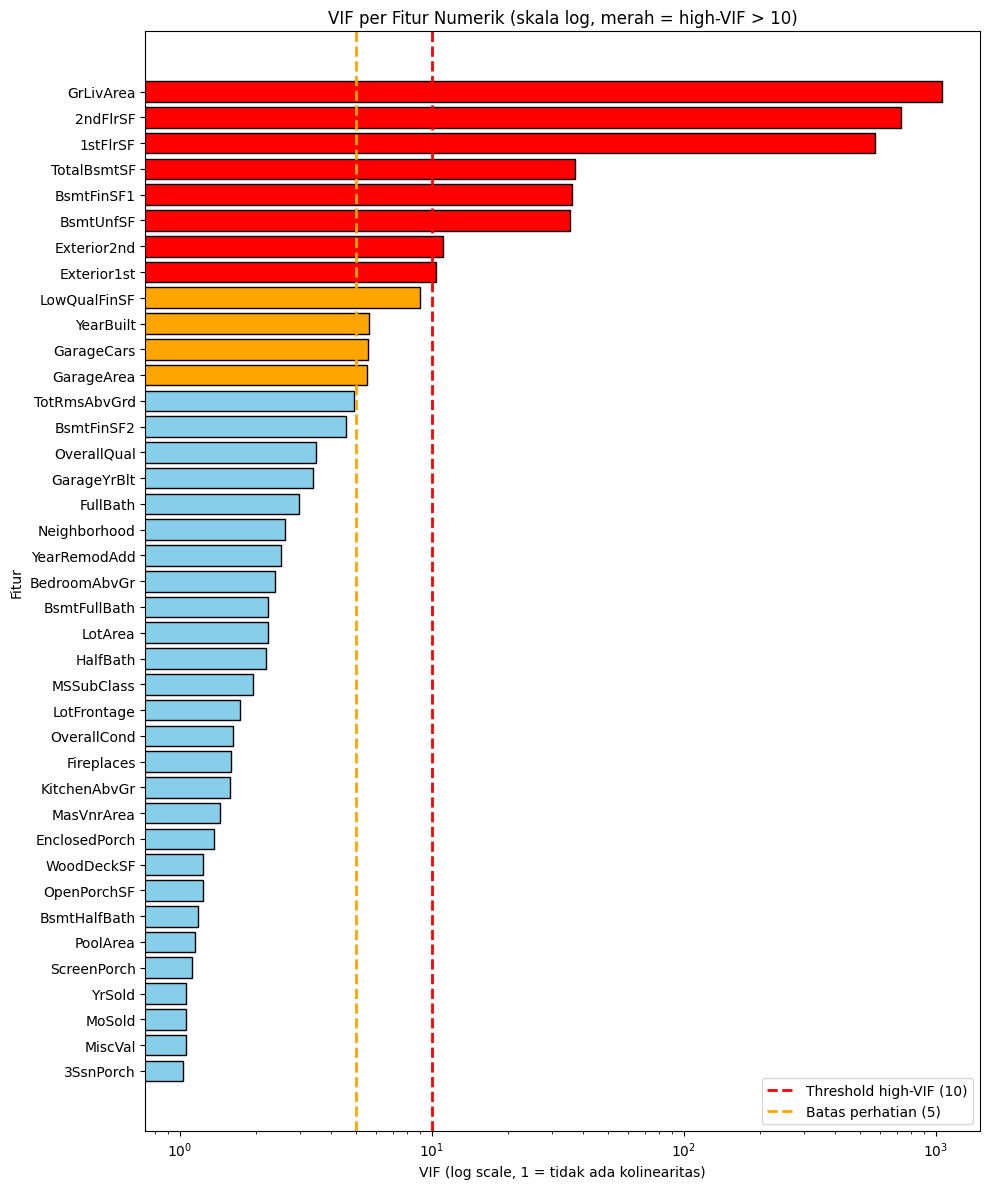

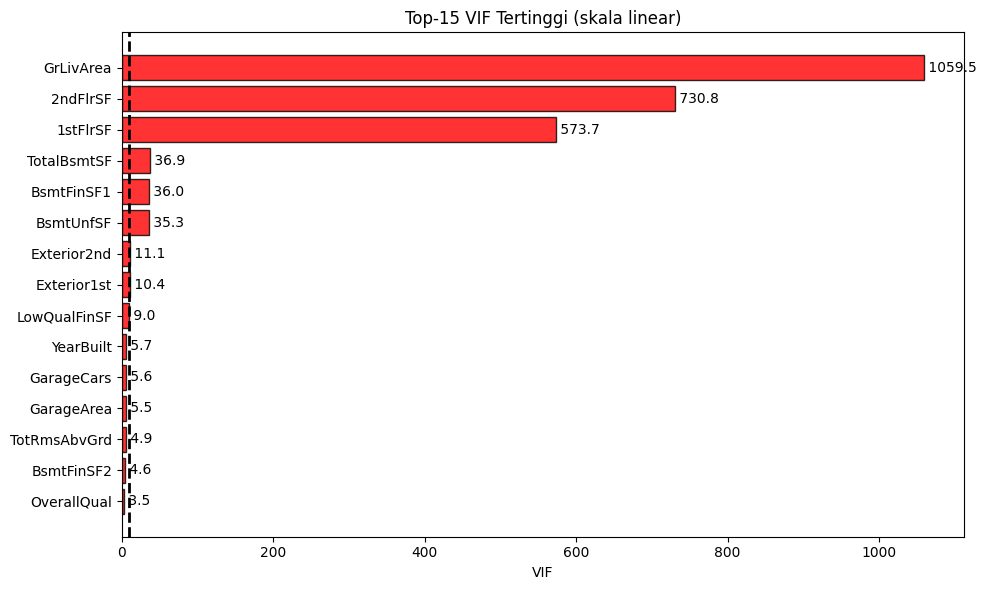

In [62]:
# --- Visualisasi VIF & konfirmasi fitur High-VIF ---
VIF_THRESHOLD = 10  # sama dengan sel sebelumnya

vif_sorted = vif_data.sort_values("VIF", ascending=True).reset_index(drop=True)
high_vif_features = vif_sorted.loc[vif_sorted["VIF"] > VIF_THRESHOLD, "feature"].tolist()
low_vif_features = vif_sorted.loc[vif_sorted["VIF"] <= VIF_THRESHOLD, "feature"].tolist()

print(f"Threshold VIF      : > {VIF_THRESHOLD}")
print(f"Jumlah high-VIF    : {len(high_vif_features)} fitur")
print(f"High-VIF           : {high_vif_features}")
print(f"Low-VIF (dipertahankan): {low_vif_features}")

colors = ["red" if v > VIF_THRESHOLD else ("orange" if v > 5 else "skyblue") for v in vif_sorted["VIF"]]

plt.figure(figsize=(10, 12))
plt.barh(vif_sorted["feature"], vif_sorted["VIF"], color=colors, edgecolor="k")
plt.axvline(VIF_THRESHOLD, color="red", linestyle="--", linewidth=2, label=f"Threshold high-VIF ({VIF_THRESHOLD})")
plt.axvline(5, color="orange", linestyle="--", linewidth=2, label="Batas perhatian (5)")
plt.xscale("log")  # rentang VIF 1 s.d. 28000+ sehingga skala log agar terbaca
plt.title("VIF per Fitur Numerik (skala log, merah = high-VIF > 10)")
plt.xlabel("VIF (log scale, 1 = tidak ada kolinearitas)")
plt.ylabel("Fitur")
plt.legend()
plt.tight_layout()
plt.show()

top15 = vif_data.sort_values("VIF", ascending=False).head(15).sort_values("VIF", ascending=True)
plt.figure(figsize=(10, 6))
plt.barh(top15["feature"], top15["VIF"], color="red", edgecolor="k", alpha=0.8)
for i, v in enumerate(top15["VIF"]):
    plt.text(v, i, f" {v:.1f}", va="center", fontsize=10)
plt.axvline(VIF_THRESHOLD, color="black", linestyle="--", linewidth=2)
plt.title("Top-15 VIF Tertinggi (skala linear)")
plt.xlabel("VIF")
plt.tight_layout()
plt.show()


Matriks PCA: 1460 baris × 8 fitur high-VIF
 PC  Explained (%)  Cumulative (%)
PC1          36.82           36.82
PC2          22.79           59.61
PC3          18.97           78.58
PC4          17.04           95.62
PC5           3.17           98.80
PC6           0.66           99.45
PC7           0.50           99.95
PC8           0.05          100.00
Komponen untuk ≥ 80% variance: 4 PC (aktual 95.62%)
Komponen untuk ≥ 90% variance: 4 PC (aktual 95.62%)
Komponen untuk ≥ 95% variance: 4 PC (aktual 95.62%)


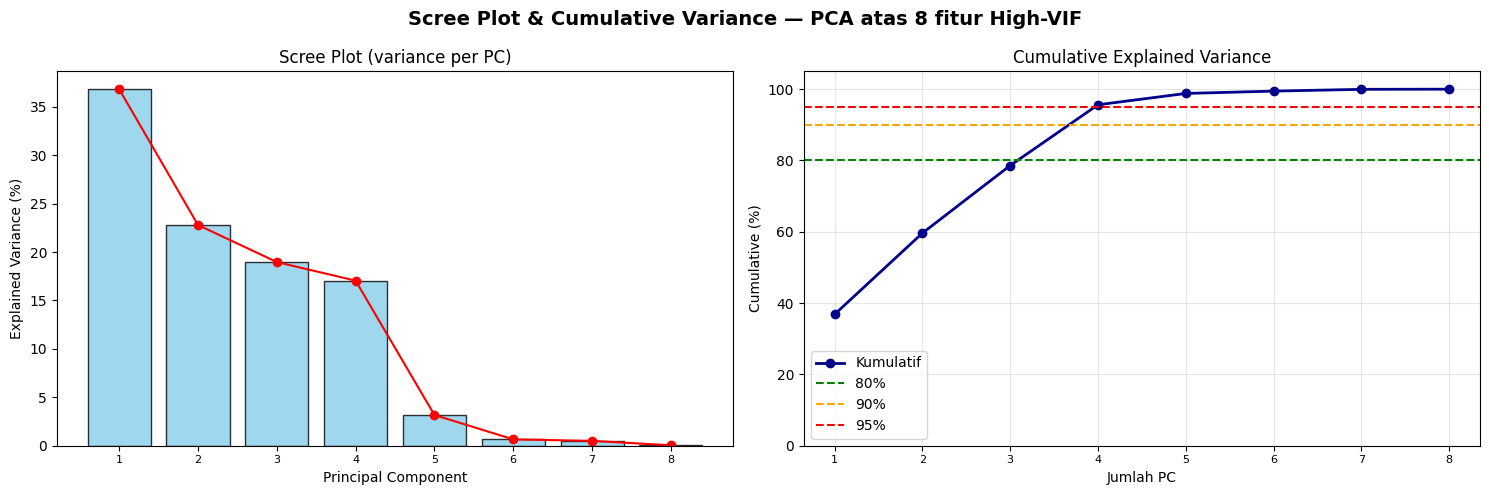

In [63]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

X_high = X.loc[:, high_vif_features]
print(f"Matriks PCA: {X_high.shape[0]} baris × {X_high.shape[1]} fitur high-VIF")

X_scaled_high = StandardScaler().fit_transform(X_high)

pca_full = PCA(random_state=SEED)
pca_full.fit(X_scaled_high)

evr = pca_full.explained_variance_ratio_
cum_evr = evr.cumsum()
n_feat = len(high_vif_features)

evr_table = pd.DataFrame({
    "PC": [f"PC{i+1}" for i in range(n_feat)],
    "Explained (%)": (evr * 100).round(2),
    "Cumulative (%)": (cum_evr * 100).round(2),
})
print(evr_table.to_string(index=False))
for t in [0.80, 0.90, 0.95]:
    k = int((cum_evr < t).sum() + 1)
    print(f"Komponen untuk ≥ {int(t*100)}% variance: {k} PC (aktual {cum_evr[k-1]*100:.2f}%)")

fig, ax = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle(f"Scree Plot & Cumulative Variance — PCA atas {n_feat} fitur High-VIF", fontsize=14, fontweight="bold")

x = np.arange(1, n_feat + 1)
ax[0].bar(x, evr * 100, color="skyblue", edgecolor="k", alpha=0.8)
ax[0].plot(x, evr * 100, color="red", marker="o")
ax[0].set_xticks(x)
ax[0].set_xticklabels([f"{i}" for i in x], fontsize=8)
ax[0].set_title("Scree Plot (variance per PC)")
ax[0].set_xlabel("Principal Component")
ax[0].set_ylabel("Explained Variance (%)")

ax[1].plot(x, cum_evr * 100, color="darkblue", marker="o", linewidth=2, label="Kumulatif")
ax[1].axhline(80, color="green", linestyle="--", label="80%")
ax[1].axhline(90, color="orange", linestyle="--", label="90%")
ax[1].axhline(95, color="red", linestyle="--", label="95%")
ax[1].set_xticks(x)
ax[1].set_xticklabels([f"{i}" for i in x], fontsize=8)
ax[1].set_title("Cumulative Explained Variance")
ax[1].set_xlabel("Jumlah PC")
ax[1].set_ylabel("Cumulative (%)")
ax[1].set_ylim(0, 105)
ax[1].legend()
ax[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


Loadings (kontribusi tiap fitur ke tiap PC) — 6 PC pertama:
               PC1    PC2    PC3    PC4    PC5    PC6
Exterior1st  0.354 -0.411 -0.365 -0.261  0.087  0.671
Exterior2nd  0.349 -0.419 -0.369 -0.257  0.017 -0.670
BsmtUnfSF    0.248 -0.266 -0.004  0.693 -0.310 -0.154
BsmtFinSF1   0.240  0.495 -0.035 -0.498 -0.340 -0.171
TotalBsmtSF  0.494  0.288 -0.041  0.177 -0.517  0.214
1stFlrSF     0.474  0.323  0.040  0.187  0.619 -0.050
2ndFlrSF     0.064 -0.383  0.635 -0.258 -0.258  0.022
GrLivArea    0.401 -0.081  0.568 -0.072  0.252 -0.021

Kontributor |PC1| terbesar (pemicu utama kolinearitas):
TotalBsmtSF    0.494
1stFlrSF       0.474
GrLivArea      0.401
Exterior1st    0.354
Exterior2nd    0.349
BsmtUnfSF      0.248
BsmtFinSF1     0.240
2ndFlrSF       0.064


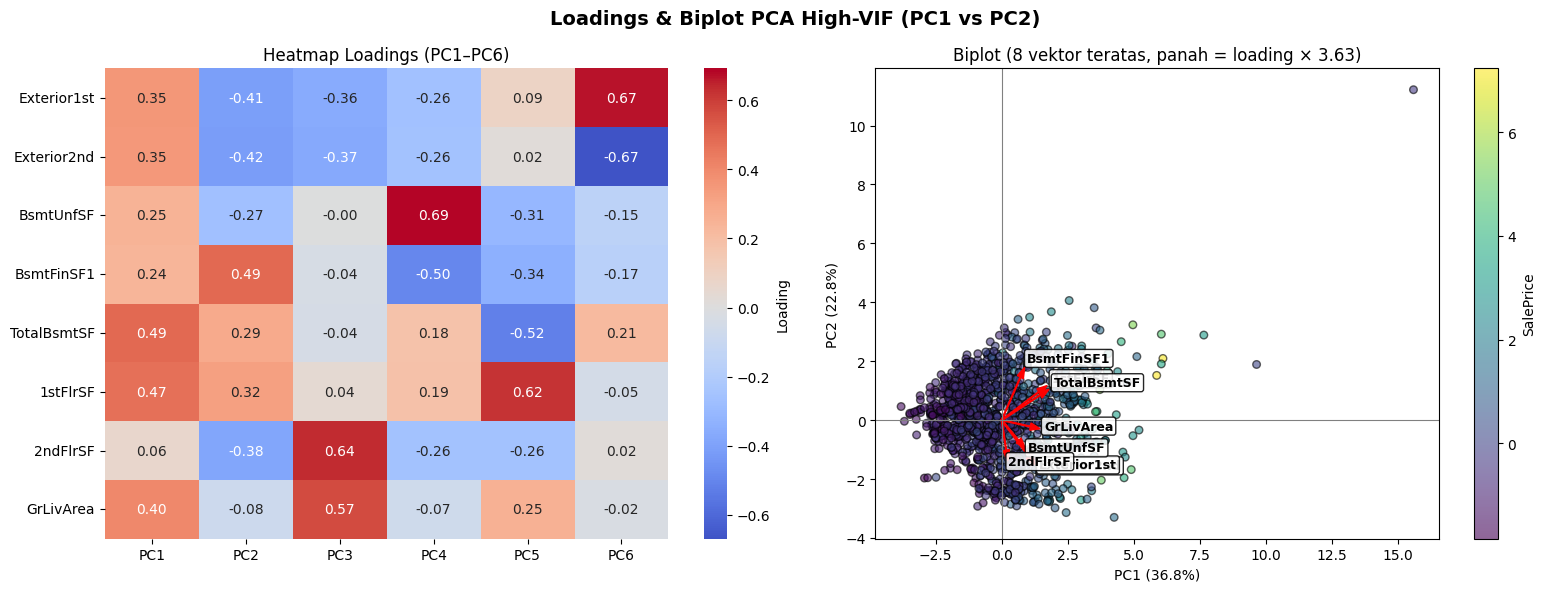

In [64]:
loadings = pd.DataFrame(
    pca_full.components_.T,
    index=high_vif_features,
    columns=[f"PC{i+1}" for i in range(n_feat)],
)
print("Loadings (kontribusi tiap fitur ke tiap PC) — 6 PC pertama:")
print(loadings.iloc[:, :6].round(3).to_string())
print("\nKontributor |PC1| terbesar (pemicu utama kolinearitas):")
print(loadings["PC1"].abs().sort_values(ascending=False).head(10).round(3).to_string())

X_2d = pca_full.transform(X_scaled_high)[:, :2]
pc_df = pd.DataFrame(X_2d, columns=["PC1", "PC2"], index=X_high.index)
pc_df[TARGET] = df.loc[X_high.index, TARGET].values

fig, ax = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Loadings & Biplot PCA High-VIF (PC1 vs PC2)", fontsize=14, fontweight="bold")

sns.heatmap(loadings.iloc[:, :6], annot=True, fmt=".2f", cmap="coolwarm", center=0,
            ax=ax[0], cbar_kws={"label": "Loading"})
ax[0].set_title("Heatmap Loadings (PC1–PC6)")

top_vec = loadings[["PC1", "PC2"]].abs().sum(axis=1).sort_values(ascending=False).head(8).index.tolist()
sc = ax[1].scatter(pc_df["PC1"], pc_df["PC2"], c=pc_df[TARGET], cmap="viridis", alpha=0.6, edgecolor="k", s=30)
plt.colorbar(sc, ax=ax[1], label="SalePrice")
scale = min(pc_df["PC1"].max() - pc_df["PC1"].min(), pc_df["PC2"].max() - pc_df["PC2"].min()) / 4.0
for feat in top_vec:
    vx, vy = loadings.loc[feat, "PC1"] * scale, loadings.loc[feat, "PC2"] * scale
    ax[1].arrow(0, 0, vx, vy, color="red", width=0.03, head_width=0.25, length_includes_head=True)
    ax[1].text(vx * 1.1, vy * 1.1, feat, fontsize=9, fontweight="bold",
               bbox=dict(boxstyle="round,pad=0.2", fc="white", alpha=0.85))
ax[1].axhline(0, color="gray", linewidth=0.8)
ax[1].axvline(0, color="gray", linewidth=0.8)
ax[1].set_title(f"Biplot (8 vektor teratas, panah = loading × {scale:.2f})")
ax[1].set_xlabel(f"PC1 ({evr[0]*100:.1f}%)")
ax[1].set_ylabel(f"PC2 ({evr[1]*100:.1f}%)")

plt.tight_layout()
plt.show()


Komponen optimal (≥90% variance): 4 PC → 95.62% variance retained (dari 8 fitur)
Shape df awal            : (1460, 195)
Shape gabungan df_combined: (1460, 191)  (kolom high-VIF 8 → 4 PC)
Kolom PC baru: ['PC1', 'PC2', 'PC3', 'PC4']


,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF2,LowQualFinSF,...,LandSlope_Sev,PavedDrive_P,PavedDrive_Y,Street_Pave,Utilities_NoSeWa,CentralAir_Y,PC1,PC2,PC3,PC4
Id,,,,,,,,,,,,,,,,,,,,,
1,0.073375,-0.220875,-0.133270,0.651479,-0.517200,1.050994,0.878668,0.514104,-0.355342,-0.133602,...,False,False,True,True,False,True,0.308875,-1.254045,0.099810,-2.074672
2,-0.872563,0.460320,0.113413,-0.071836,2.179628,0.156734,-0.429577,-0.570750,-0.355342,-0.133602,...,False,False,True,True,False,True,-0.541432,2.222575,-0.020945,-0.088869
3,0.073375,-0.084636,0.420049,0.651479,-0.517200,0.984752,0.830215,0.325915,-0.355342,-0.133602,...,False,False,True,True,False,True,0.562494,-1.590283,0.214722,-1.349753
4,0.309859,-0.447940,0.103317,0.651479,-0.517200,-1.863632,-0.720298,-0.570750,-0.355342,-0.133602,...,False,False,True,True,False,True,-1.104071,-0.288070,1.457065,0.156070
5,0.073375,0.641972,0.878431,1.374795,-0.517200,0.951632,0.733308,1.366489,-0.355342,-0.133602,...,False,False,True,True,False,True,1.554255,-1.332242,0.921598,-1.414707



VIF SESUDAH PCA (harus ≈ 1.0):
feature  VIF
    PC1  1.0
    PC2  1.0
    PC3  1.0
    PC4  1.0

Korelasi antar-PC (harus ≈ 0):
     PC1  PC2  PC3  PC4
PC1  1.0 -0.0 -0.0 -0.0
PC2 -0.0  1.0  0.0  0.0
PC3 -0.0  0.0  1.0  0.0
PC4 -0.0  0.0  0.0  1.0


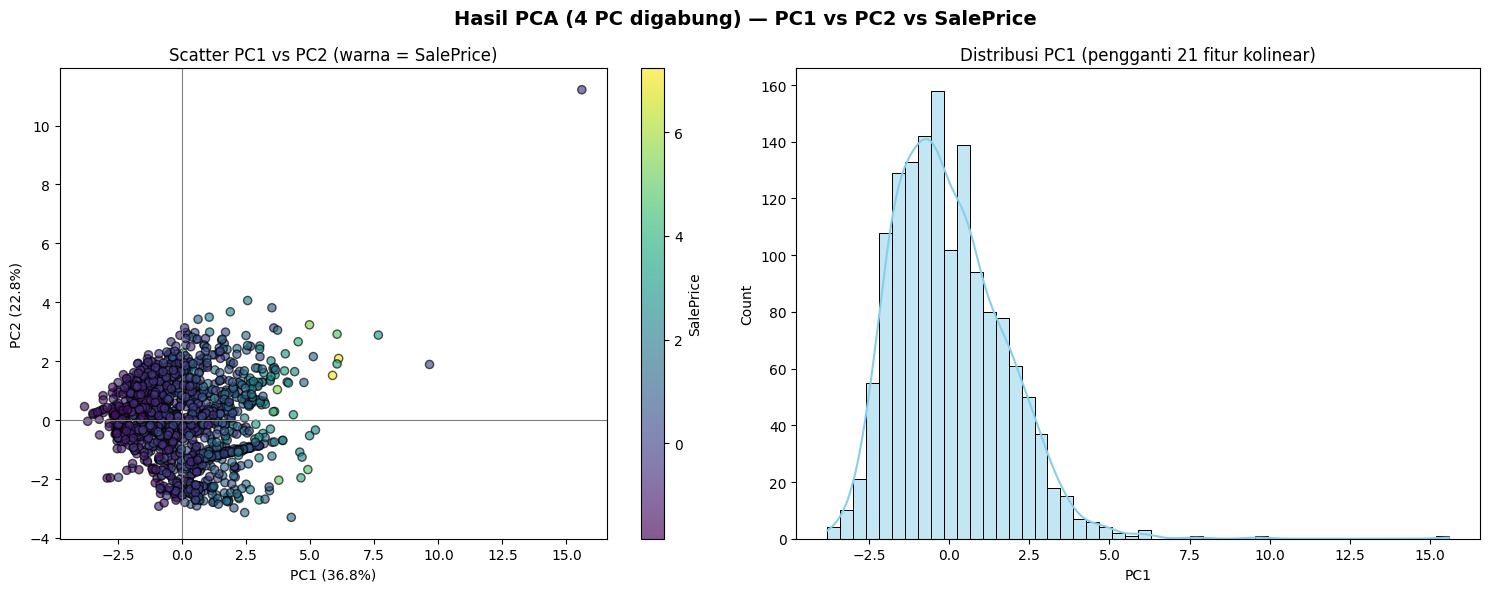

In [65]:
# Pilih k agar kumulatif ≥ 90%
cum_evr = pca_full.explained_variance_ratio_.cumsum()
n_opt = int((cum_evr < 0.90).sum() + 1)
n_opt = max(2, min(n_opt, len(high_vif_features)))
print(f"Komponen optimal (≥90% variance): {n_opt} PC → {cum_evr[n_opt-1]*100:.2f}% variance retained (dari {len(high_vif_features)} fitur)")

pca_opt = PCA(n_components=n_opt, random_state=SEED)
X_pca_opt = pca_opt.fit_transform(X_scaled_high)
pc_cols = [f"PC{i+1}" for i in range(n_opt)]
df_pca = pd.DataFrame(X_pca_opt, columns=pc_cols, index=X_high.index)

df_combined = pd.concat(
    [df.loc[X_high.index].drop(columns=high_vif_features), df_pca],
    axis=1,
)
print(f"Shape df awal            : {df.shape}")
print(f"Shape gabungan df_combined: {df_combined.shape}  (kolom high-VIF {len(high_vif_features)} → {n_opt} PC)")
print(f"Kolom PC baru: {pc_cols}")
display(df_combined.head())

Xc_after = df_pca - df_pca.mean()
vif_after = pd.DataFrame({
    "feature": df_pca.columns,
    "VIF": [variance_inflation_factor(Xc_after.values, i) for i in range(df_pca.shape[1])],
})
print("\nVIF SESUDAH PCA (harus ≈ 1.0):")
print(vif_after.to_string(index=False))
print("\nKorelasi antar-PC (harus ≈ 0):")
print(df_pca.corr().round(3).to_string())

df_plot_pca = df_pca.copy()
df_plot_pca[TARGET] = df.loc[X_high.index, TARGET].values

fig, ax = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle(f"Hasil PCA ({n_opt} PC digabung) — PC1 vs PC2 vs SalePrice", fontsize=14, fontweight="bold")

sc = ax[0].scatter(df_plot_pca["PC1"], df_plot_pca["PC2"], c=df_plot_pca[TARGET],
                   cmap="viridis", alpha=0.65, edgecolor="k", s=35)
plt.colorbar(sc, ax=ax[0], label="SalePrice")
ax[0].axhline(0, color="gray", linewidth=0.8)
ax[0].axvline(0, color="gray", linewidth=0.8)
ax[0].set_title("Scatter PC1 vs PC2 (warna = SalePrice)")
ax[0].set_xlabel(f"PC1 ({pca_full.explained_variance_ratio_[0]*100:.1f}%)")
ax[0].set_ylabel(f"PC2 ({pca_full.explained_variance_ratio_[1]*100:.1f}%)")

sns.histplot(data=df_plot_pca, x="PC1", kde=True, color="skyblue", ax=ax[1])
ax[1].set_title("Distribusi PC1 (pengganti 21 fitur kolinear)")

plt.tight_layout()
plt.show()
